<a href="https://colab.research.google.com/github/navspeak/ML/blob/main/Regularisation_Assg_Car_Price_Prediction_Starter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicting Vehicle Prices Using Regression Models

## **Objectives**  
The primary goal of this project is to develop a robust regression model to predict used car prices for a reseller based on various listed features and specifications. In addition to predicting prices, the project focuses on identifying feature importance and mitigating overfitting through the application of regularisation techniques.

There can be several business objectives for this, such as:

* **Price Prediction**: Model car prices based on features like mileage, fuel type, and performance.
* **Market Analysis**: Explore trends and preferences in the used car market, by type, region, or other metrics.
* **Feature Importance**: Identify the most important factors influencing car prices (e.g., fuel type, mileage, age).

### **Tasks Overview**
The data pipeline for this task involves the following steps:  
1. **Dataset Overview**   
2. **Data Preprocessing**
3. **Data Visualisation & Exploration**
4. **Model Building**
3. **Regularisation**

## **1 Data Understanding**

| **Variable** | **Description** |
|-|-|
| `make_model` | The brand and model of the vehicle (e.g., 'Audi A1'). |
| `body_type` | The body style of the vehicle, such as Sedan, Compact, or Station Wagon. |
| `price`  | The listed price of the car in currency. |
| `vat`  | Indicates the VAT status for the vehicle's price (e.g., VAT deductible, Price negotiable). |
| `km` | The total mileage (in kilometers) of the vehicle, indicating its usage. |
| `Type` | Condition of the vehicle, whether it's 'Used' or 'New'.|
| `Fuel` | Type of fuel the vehicle uses, such as 'Diesel', 'Benzine', etc. |
| `Gears` | The number of gears in the vehicle's transmission. |
| `Comfort_Convenience` | Comfort and convenience features, such as 'Air conditioning', 'Leather steering wheel', 'Cruise control', and more. |
| `Entertainment_Media` | Media features available in the vehicle, including 'Bluetooth', 'MP3', 'Radio', etc. |
| `Extras` | Additional features like 'Alloy wheels', 'Sport suspension', etc.|
| `Safety_Security` | Safety features like 'ABS', 'Airbags', 'Electronic stability control', 'Isofix', etc.  |
| `age` | Age of the car (calculated based on the model year). |
| `Previous_Owners`| The number of previous owners the car has had. |
| `hp_kW` | Engine power in kilowatts (kW), indicating the performance capacity of the engine.|
| `Inspection_new` | Indicates whether the car has recently undergone an inspection (1 for yes, 0 for no). |
| `Paint_Type`| The type of paint on the car, such as 'Metallic', 'Matte', etc. |
| `Upholstery_type` | The material used for the interior upholstery, such as 'Cloth', 'Leather', etc.|
| `Gearing_Type` | The type of transmission the car uses, either 'Automatic' or 'Manual'. |
| `Displacement_cc` | The engine displacement in cubic centimeters (cc), indicating the size of the engine.|
| `Weight_kg` | The total weight of the vehicle in kilograms.|
| `Drive_chain` | The type of drivetrain, indicating whether it's 'Front' or 'Rear' wheel drive. |
| `cons_comb`  | The combined fuel consumption in liters per 100 kilometers.|

### **1.1 Data Loading**

**Importing Necessary Libraries**

In [626]:
# Importing necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
import numpy as np
import warnings



In [627]:
from google.colab import drive
drive.mount('/content/drive')
warnings.filterwarnings('ignore')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#### **1.1.1**
Load the dataset

In [628]:
# Load the data
df = pd.read_csv('/content/drive/MyDrive/ML/Car_Price_data.csv')
df.info()
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15915 entries, 0 to 15914
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   make_model           15915 non-null  object 
 1   body_type            15915 non-null  object 
 2   price                15915 non-null  int64  
 3   vat                  15915 non-null  object 
 4   km                   15915 non-null  float64
 5   Type                 15915 non-null  object 
 6   Fuel                 15915 non-null  object 
 7   Gears                15915 non-null  float64
 8   Comfort_Convenience  15915 non-null  object 
 9   Entertainment_Media  15915 non-null  object 
 10  Extras               15915 non-null  object 
 11  Safety_Security      15915 non-null  object 
 12  age                  15915 non-null  float64
 13  Previous_Owners      15915 non-null  float64
 14  hp_kW                15915 non-null  float64
 15  Inspection_new       15915 non-null 

,make_model,body_type,price,vat,km,Type,Fuel,Gears,Comfort_Convenience,Entertainment_Media,...,Previous_Owners,hp_kW,Inspection_new,Paint_Type,Upholstery_type,Gearing_Type,Displacement_cc,Weight_kg,Drive_chain,cons_comb
0,Audi A1,Sedans,15770,VAT deductible,56013.0,Used,Diesel,7.0,"Air conditioning,Armrest,Automatic climate con...","Bluetooth,Hands-free equipment,On-board comput...",...,2.0,66.0,1,Metallic,Cloth,Automatic,1422.0,1220.0,front,3.8
1,Audi A1,Sedans,14500,Price negotiable,80000.0,Used,Benzine,7.0,"Air conditioning,Automatic climate control,Hil...","Bluetooth,Hands-free equipment,On-board comput...",...,1.0,141.0,0,Metallic,Cloth,Automatic,1798.0,1255.0,front,5.6
2,Audi A1,Sedans,14640,VAT deductible,83450.0,Used,Diesel,7.0,"Air conditioning,Cruise control,Electrical sid...","MP3,On-board computer",...,1.0,85.0,0,Metallic,Cloth,Automatic,1598.0,1135.0,front,3.8
3,Audi A1,Sedans,14500,VAT deductible,73000.0,Used,Diesel,6.0,"Air suspension,Armrest,Auxiliary heating,Elect...","Bluetooth,CD player,Hands-free equipment,MP3,O...",...,1.0,66.0,0,Metallic,Cloth,Automatic,1422.0,1195.0,front,3.8
4,Audi A1,Sedans,16790,VAT deductible,16200.0,Used,Diesel,7.0,"Air conditioning,Armrest,Automatic climate con...","Bluetooth,CD player,Hands-free equipment,MP3,O...",...,1.0,66.0,1,Metallic,Cloth,Automatic,1422.0,1135.0,front,4.1


## **2 Analysis and Feature Engineering** <font color =red> [35 marks] </font>



### **2.1 Preliminary Analysis and Frequency Distributions** <font color = red> [13 marks] </font>

#### **2.1.1** <font color =red> [1 marks] </font>
Check and fix missing values.

In [629]:
# Find the proportion of missing values in each column and handle if found
missing_values = df.isnull().mean().sort_values(ascending=False)
missing_values = missing_values[missing_values > 0]  # keep only columns with missing

if missing_values.empty:
    print("There are no missing values in any column")
else:
    print(f"{len(missing_values)} columns have missing values:\n")
    print(missing_values.map(lambda x: f"{x:.1%}"))


There are no missing values in any column


**From the features, identify the target feature and numerical and categorical predictors. Select the numerical and categorical features carefully as they will be used in analysis.**

#### **2.1.2** <font color =red> [3 marks] </font>
Identify numerical predictors and plot their frequency distributions.

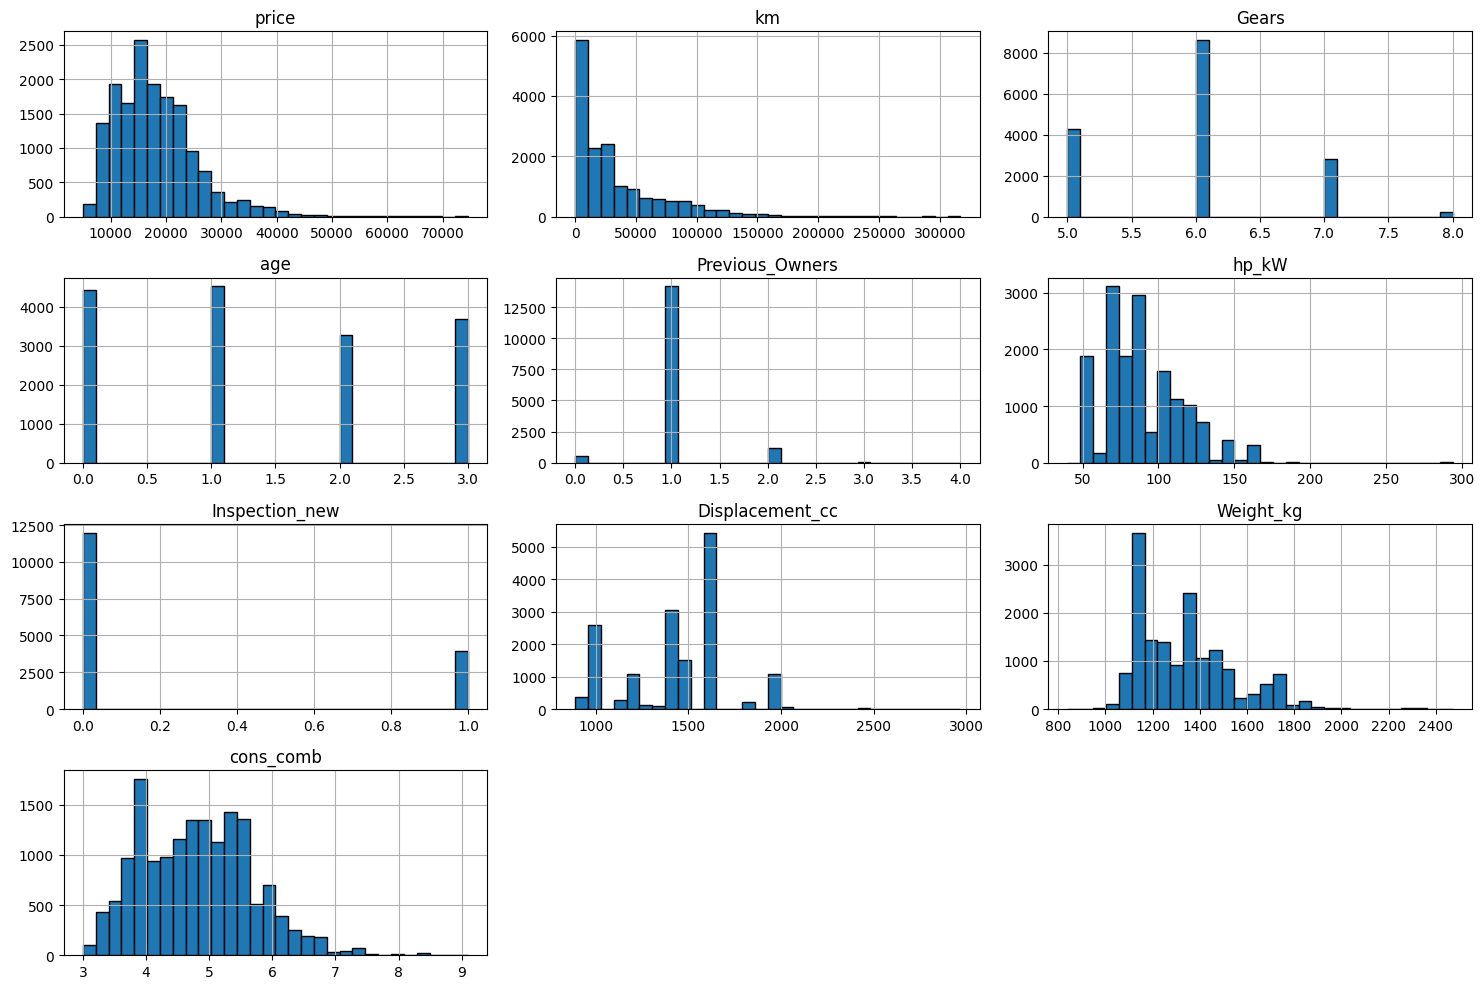

In [630]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[numerical_cols].hist(bins=30, figsize=(15, 10), edgecolor='black')
plt.tight_layout()
plt.show()


*  Many numerical features like `price`, `km`, `hp_kW`, `Displacement_cc`, `Weight_kg`, `cons_comb` exhibit right-skewed distributions.
*  `Gears` has low cardinality, predominantly showing values of 5, 6, or 7.
*  `Inspection_new` is a binary feature (0 or 1).
*  `age` and `Previous_Owners` are discrete numerical features with limited ranges, also showing skewed distributions.

#### **2.1.3** <font color =red> [3 marks] </font>
Identify categorical predictors and plot their frequency distributions.

In [631]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print("Categorical columns:", categorical_cols)

nunique = df[categorical_cols].nunique().sort_values(ascending=False)
print(nunique)

high_cardinality = nunique[nunique > 100].index.tolist()
low_cardinality = nunique[nunique <= 100].index.tolist()

if high_cardinality:
    print(f"\nHigh cardinality columns (nunique > 100): {high_cardinality}")
    print("These cannot be treated as NORMAL categorical columns directly.")
    print("Consider exploding (if comma-separated), label encoding, or dropping them before modelling.\n")

print(f"Columns suitable for categorical analysis: {low_cardinality}")

Categorical columns: ['make_model', 'body_type', 'vat', 'Type', 'Fuel', 'Comfort_Convenience', 'Entertainment_Media', 'Extras', 'Safety_Security', 'Paint_Type', 'Upholstery_type', 'Gearing_Type', 'Drive_chain']
Comfort_Convenience    6196
Safety_Security        4442
Extras                  659
Entertainment_Media     346
make_model                9
body_type                 8
Type                      5
Fuel                      4
Paint_Type                3
Drive_chain               3
Gearing_Type              3
vat                       2
Upholstery_type           2
dtype: int64

High cardinality columns (nunique > 100): ['Comfort_Convenience', 'Safety_Security', 'Extras', 'Entertainment_Media']
These cannot be treated as NORMAL categorical columns directly.
Consider exploding (if comma-separated), label encoding, or dropping them before modelling.

Columns suitable for categorical analysis: ['make_model', 'body_type', 'Type', 'Fuel', 'Paint_Type', 'Drive_chain', 'Gearing_Type', 'vat

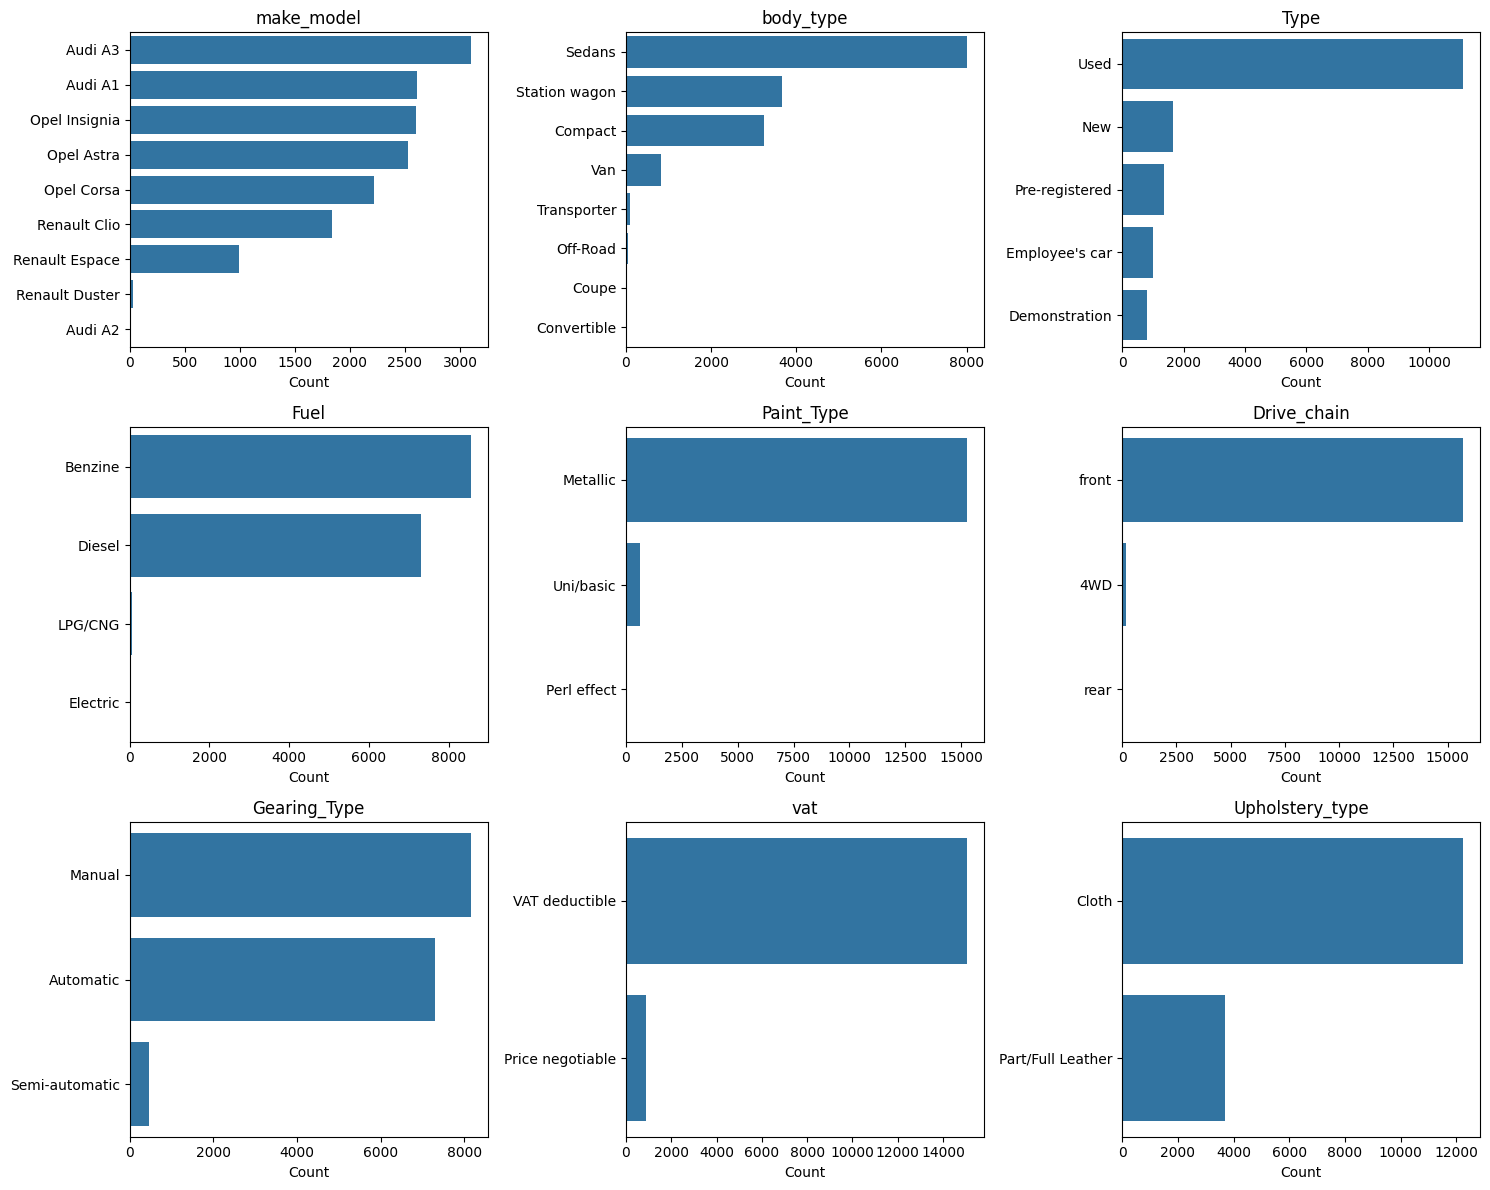

In [632]:
import math
n = len(low_cardinality)
cols = 3
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 4))
axes = axes.flatten()

for i, col in enumerate(low_cardinality):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('Count')
    axes[i].set_ylabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [633]:
df["Comfort_Convenience"].head()
# df["Entertainment_Media"].head()
df['Comfort_Convenience'].str.split(',').explode().value_counts()

,count
Comfort_Convenience,
Air conditioning,15095
Power windows,14756
Electrical side mirrors,12488
Multi-function steering wheel,11744
Cruise control,11622
Park Distance Control,10655
Parking assist system sensors rear,10086
Leather steering wheel,9735
Start-stop system,9455


**Note**: Look carefully at the values stored in columns `["Comfort_Convenience", "Entertainment_Media", "Extras", "Safety_Security"]`.

Should they be considered categorical? Should they be dropped or handled any other way?

## Should they be considered categorical?
- As we have seen in above cells, these columns have high cardinality
  - Comfort_Convenience   -> 6196
  - Safety_Security       -> 4442
  - Extras                -> 659
  - Entertainment_Media   -> 346
- And Each value is a comma-separated list of features, e.g. `"Air conditioning, Cruise control, Navigation system"`. So each row represent a set of features (multi-label), not a single category.
- One-hot encoding them directly would create thousands of meaningless dummy columns (one per unique combination)
- A categorical column assumes a fixed set of mutually exclusive classes — these columns violate that assumption entirely
- **So, they should NOT be treated as standard (single-label) categorical variables, but rather as multi-label categorical features requiring special encoding.**

## Should they be dropped or handled any other way?
- 🚩 **Option 1**: **Dropping** these columns can be done only if we believe these features don't help predict your target (e.g. car price). Simple but we lose potentially useful information. So, at this point, I will **NOT DROP**
-  **Option 2**: **Count the features**. Instead of what features a car has, just **count how many it has**. The intuition is simple that a car with 10 comfort features is probably more expensive than one with 2, regardless of exactly which features they are.** We turn an unusable text column into a useful numeric one**. E.g.:
|row| Comfort_Convenience|Comfort_Convenience_count|
|-|-|-|
|1|"Air conditioning, Cruise control, Navigation"|3|
|2|"Air conditioning, Seat heating"|2|
- ✔️ **Option 3**:  **Binarize (one column per feature)**.
Create a separate 0/1 column for every individual feature. It is most informative approach but it creates many new colums. Slower model and harder to interpret
|row|Air conditioning|Cruise control|Navigation|Seat heating|
|-|-|-|-|-|
|1|1|1|1|0|
|2|1|0|0|1|


In [634]:
#option 2
df_option_2 = df.copy()
for col in ['Comfort_Convenience', 'Entertainment_Media', 'Extras', 'Safety_Security']:
    df_option_2[f'{col}_count'] = df_option_2[col].fillna('').apply(
        lambda x: len([i for i in x.split(',') if i.strip()]) if x else 0
    )
df_option_2.head()

,make_model,body_type,price,vat,km,Type,Fuel,Gears,Comfort_Convenience,Entertainment_Media,...,Upholstery_type,Gearing_Type,Displacement_cc,Weight_kg,Drive_chain,cons_comb,Comfort_Convenience_count,Entertainment_Media_count,Extras_count,Safety_Security_count
0,Audi A1,Sedans,15770,VAT deductible,56013.0,Used,Diesel,7.0,"Air conditioning,Armrest,Automatic climate con...","Bluetooth,Hands-free equipment,On-board comput...",...,Cloth,Automatic,1422.0,1220.0,front,3.8,16,4,3,14
1,Audi A1,Sedans,14500,Price negotiable,80000.0,Used,Benzine,7.0,"Air conditioning,Automatic climate control,Hil...","Bluetooth,Hands-free equipment,On-board comput...",...,Cloth,Automatic,1798.0,1255.0,front,5.6,9,5,4,15
2,Audi A1,Sedans,14640,VAT deductible,83450.0,Used,Diesel,7.0,"Air conditioning,Cruise control,Electrical sid...","MP3,On-board computer",...,Cloth,Automatic,1598.0,1135.0,front,3.8,13,2,2,12
3,Audi A1,Sedans,14500,VAT deductible,73000.0,Used,Diesel,6.0,"Air suspension,Armrest,Auxiliary heating,Elect...","Bluetooth,CD player,Hands-free equipment,MP3,O...",...,Cloth,Automatic,1422.0,1195.0,front,3.8,16,8,3,14
4,Audi A1,Sedans,16790,VAT deductible,16200.0,Used,Diesel,7.0,"Air conditioning,Armrest,Automatic climate con...","Bluetooth,CD player,Hands-free equipment,MP3,O...",...,Cloth,Automatic,1422.0,1135.0,front,4.1,13,7,4,13


In [635]:
#option 3
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()
features = df['Comfort_Convenience'].str.split(',')
encoded = pd.DataFrame(mlb.fit_transform(features), columns=mlb.classes_)
encoded

,Air conditioning,Air suspension,Armrest,Automatic climate control,Auxiliary heating,Cruise control,Electric Starter,Electric tailgate,Electrical side mirrors,Electrically adjustable seats,...,Power windows,Rain sensor,Seat heating,Seat ventilation,Split rear seats,Start-stop system,Sunroof,Tinted windows,Wind deflector,Windshield
0,1,0,1,1,0,1,0,0,1,0,...,1,1,1,0,0,1,0,0,0,0
1,1,0,0,1,0,0,0,0,0,0,...,1,0,0,0,0,1,0,1,0,0
2,1,0,0,0,0,1,0,0,1,0,...,1,0,1,0,0,1,0,0,0,0
3,0,1,1,0,1,0,0,0,1,0,...,1,1,1,0,1,1,0,0,0,0
4,1,0,1,1,0,0,0,0,1,0,...,1,1,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15910,1,0,0,1,0,1,0,0,1,1,...,1,1,0,0,1,1,0,1,0,0
15911,1,0,0,1,0,1,0,1,1,0,...,1,1,1,0,0,0,1,0,0,0
15912,1,0,1,1,0,1,0,1,1,0,...,1,1,1,1,0,0,1,0,0,0
15913,1,0,0,1,0,1,0,0,1,1,...,1,0,0,0,0,1,0,0,0,0


#### **2.1.4** <font color =red> [3 marks] </font>
Fix columns with low frequency values and class imbalances.

Some information regarding values in the `Type` column that may help:
- *'Pre-registered'* cars are ones which have already been registered previously by the seller.
- *'New'* cars are not necessarily new cars, but new-like cars. These might also have multiple owners due to multiple pre-registrations as well.
- *'Employee's car'* are cars used by employees over a short period of time and small distance.
- *'Demonstration'* cars are used for trial purposes and also driven for a short time and distance.

Based on these, you can handle this particular column. For other columns, decide a strategy on your own.

In [636]:
for col in low_cardinality:
    print(f"\n=== {col} ===")

    counts = df[col].value_counts()
    perc = df[col].value_counts(normalize=True).mul(100).round(1)

    summary = pd.DataFrame({
        'count': counts,
        'percentage': perc
    })

    print(summary)

    # Flag imbalance
    if perc.iloc[0] > 80:
        print("⚠️ Highly imbalanced column")




=== make_model ===
                count  percentage
make_model                       
Audi A3          3097        19.5
Audi A1          2614        16.4
Opel Insignia    2598        16.3
Opel Astra       2525        15.9
Opel Corsa       2216        13.9
Renault Clio     1839        11.6
Renault Espace    991         6.2
Renault Duster     34         0.2
Audi A2             1         0.0

=== body_type ===
               count  percentage
body_type                       
Sedans          8004        50.3
Station wagon   3677        23.1
Compact         3240        20.4
Van              817         5.1
Transporter       88         0.6
Off-Road          56         0.4
Coupe             25         0.2
Convertible        8         0.1

=== Type ===
                count  percentage
Type                             
Used            11095        69.7
New              1649        10.4
Pre-registered   1364         8.6
Employee's car   1011         6.4
Demonstration     796         5.0

=== 

# Summary of issues found:

|Column |Issue| Fix|
|-|-|-|
|make_model|Renault Duster 0.2%, Audi A2 0.0% |Group rare into Other|
|body_type|Transporter 0.6%, Off-Road 0.4%, Coupe 0.2%, Convertible 0.1%|Group rare into Other|
|Type|Pre-registered ≈ New, Employee's car ≈ Demonstration| Merge similar categories|
|Fuel| LPG/CNG 0.4%, Electric 0.0% |Group rare into Other|
|Paint_Type|Perl effect 0.2%, dominated by Metallic 95.8%|Group rare + flag imbalance|
|Drive_chain|rear 0.0%, dominated by front 98.7%|Review|
|Gearing_Type|Reasonable distribution|No fix needed|
|vat|Dominated by VAT deductible 94.5%|Review|
|Upholstery_type|Reasonable split 77%/23%|No fix needed|


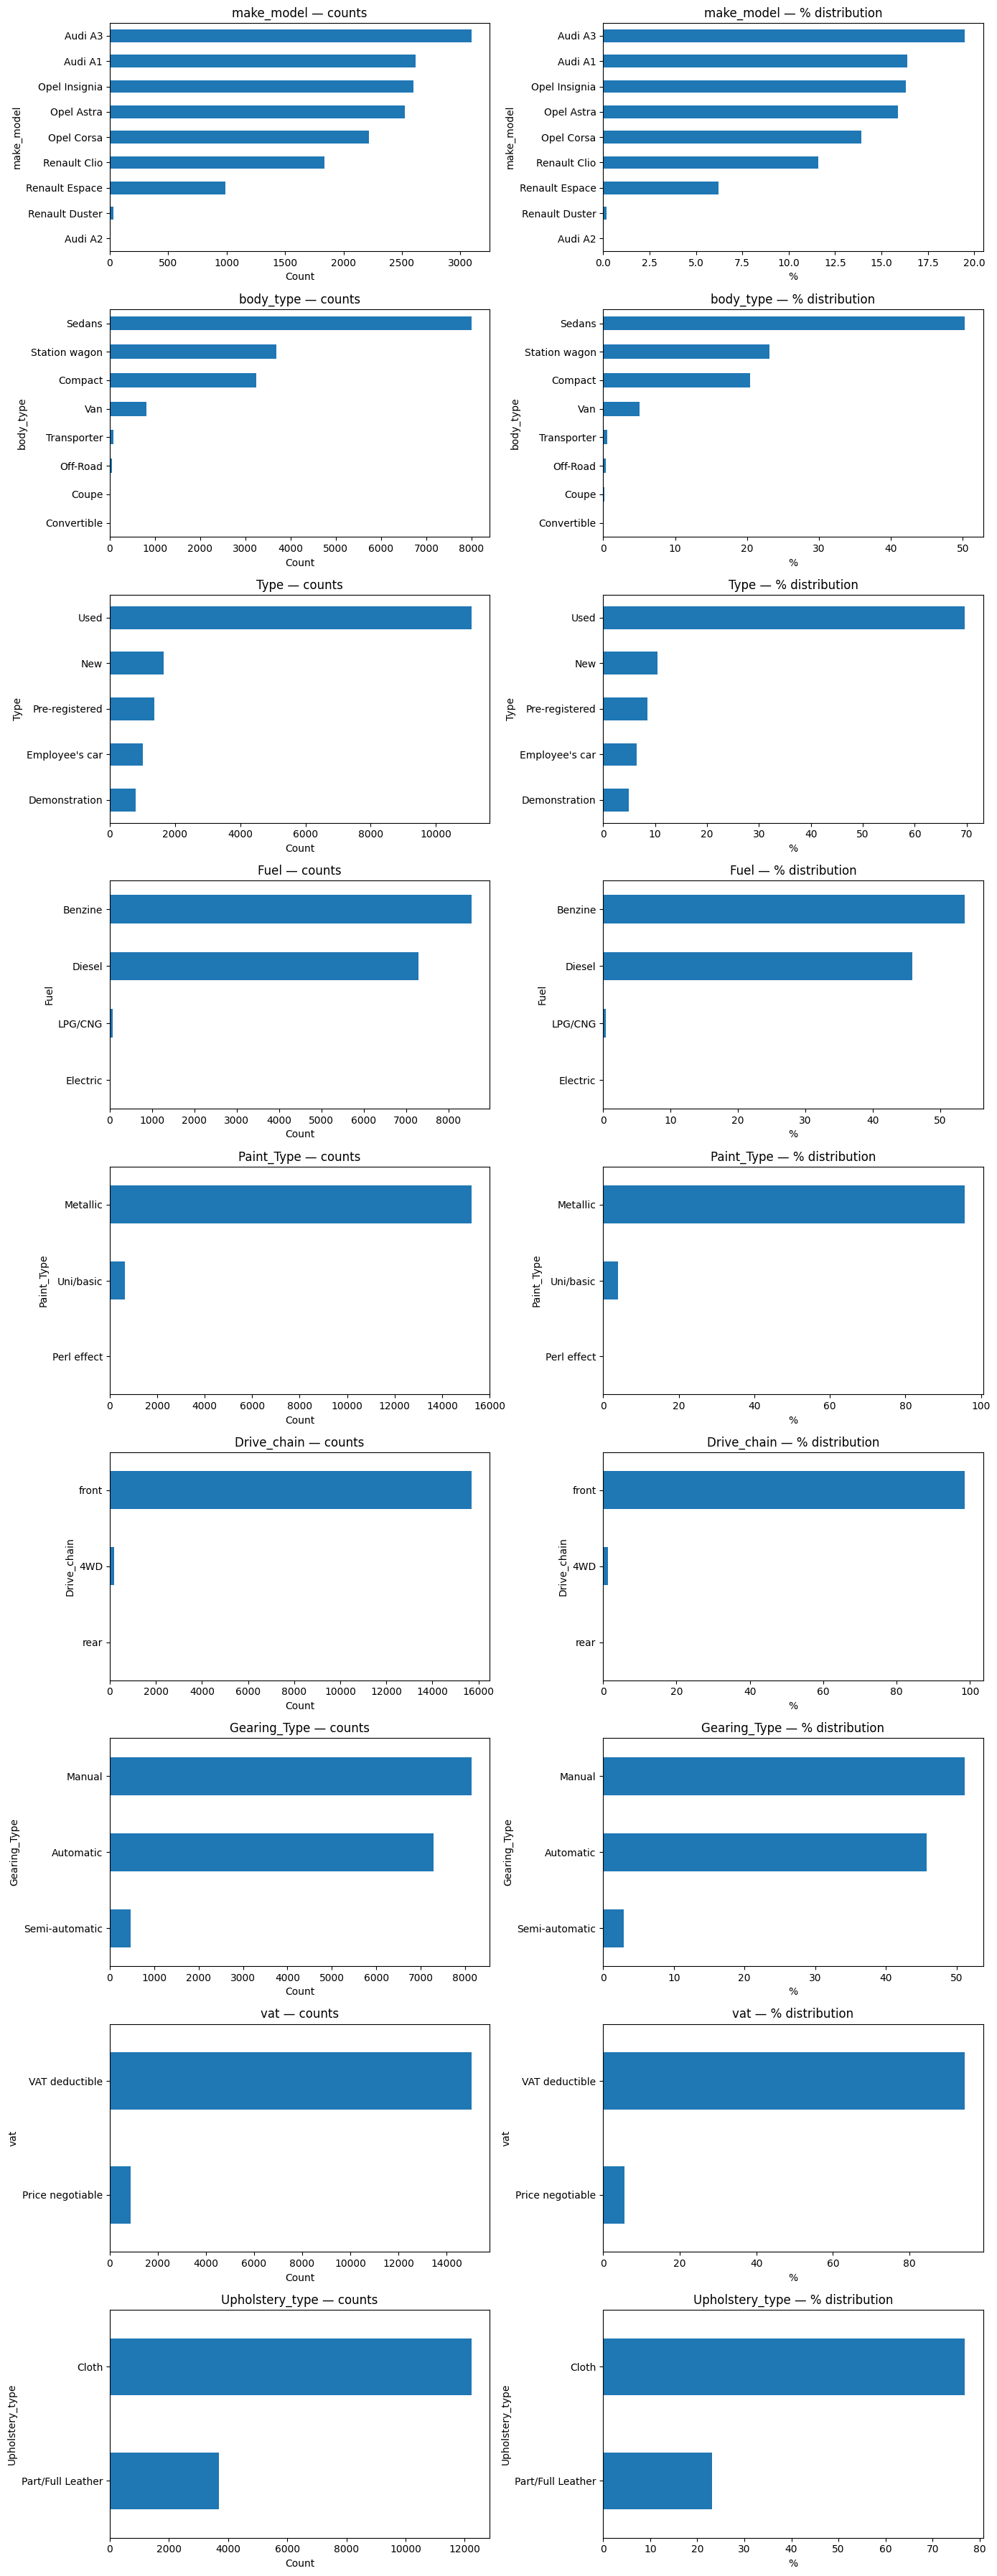

In [637]:
fig, axes = plt.subplots(len(low_cardinality), 2, figsize=(14, len(low_cardinality) * 4))

for i, col in enumerate(low_cardinality):
    # count plot
    order = df[col].value_counts().index
    df[col].value_counts().plot(kind='barh', ax=axes[i][0], title=f'{col} — counts')
    axes[i][0].set_xlabel('Count')
    axes[i][0].invert_yaxis()  # most common at top

    # percentage plot
    pct = df[col].value_counts(normalize=True).mul(100).round(1)
    pct.plot(kind='barh', ax=axes[i][1], title=f'{col} — % distribution')
    axes[i][1].set_xlabel('%')
    axes[i][1].invert_yaxis()

plt.tight_layout()
plt.show()

In [638]:
#  Step 1: Merge rare categories (threshold < 1%)
def group_rare_categories(df, col, threshold=0.01):
    freq = df[col].value_counts(normalize=True)
    rare = freq[freq < threshold].index.tolist()
    df[col] = df[col].apply(lambda x: 'Other' if x in rare else x)
    return df, rare

cols_to_group = ['make_model', 'body_type', 'Fuel', 'Paint_Type']
print("STEP 1: Grouping rare categories")
print("=" * 50)
for col in cols_to_group:
    before = df[col].nunique()
    df, rare = group_rare_categories(df, col, threshold=0.01)
    after = df[col].nunique()
    print(f"\n{col}: {before} -> {after} categories")
    print(f"  Merged into 'Other': {rare}")

#  Step 2: Merge similar categories in Type (domain knowledge)
print("\n\nSTEP 2: Merging similar Type categories")
print("=" * 50)
df['Type'] = df['Type'].replace({
    'Pre-registered': 'New',
    "Employee's car": 'Demonstration'
})
print(df['Type'].value_counts())
print("\nMerged 'Pre-registered' -> 'New'   (both new-like cars)")
print("Merged 'Employee's car' -> 'Demonstration'   (both short use, short distance)")

#  Step 3: Drop highly imbalanced columns
# print("\n\nSTEP 3: Dropping highly imbalanced columns")
# print("=" * 50)
# cols_to_drop = ['Drive_chain', 'vat', 'Paint_Type']
# for col in cols_to_drop:
#     top = df[col].value_counts(normalize=True).iloc[0]
#     print(f"Dropping '{col}' — top class is {top:.1%}, no predictive value")

# df.drop(columns=cols_to_drop, inplace=True)
# low_cardinality = [col for col in low_cardinality if col not in cols_to_drop]

print("\n\nSTEP 3: Evaluating highly imbalanced columns")
print("=" * 50)

cols_to_review = ['Drive_chain', 'vat', 'Paint_Type']

for col in cols_to_review:
    print(f"\n{col} distribution:")
    print(df[col].value_counts(normalize=True))

    print(f"\nAverage price by {col}:")
    print(df.groupby(col)['price'].mean())

#  Step 4: Final summary
print("\n\nFINAL SUMMARY — remaining categorical columns")
print("=" * 50)
for col in low_cardinality:
    dist = df[col].value_counts(normalize=True).mul(100).round(1)
    print(f"\n{col} ({df[col].nunique()} categories):")
    for cat, pct in dist.items():
        print(f"  {cat:<25} {pct}%")

STEP 1: Grouping rare categories

make_model: 9 -> 8 categories
  Merged into 'Other': ['Renault Duster', 'Audi A2']

body_type: 8 -> 5 categories
  Merged into 'Other': ['Transporter', 'Off-Road', 'Coupe', 'Convertible']

Fuel: 4 -> 3 categories
  Merged into 'Other': ['LPG/CNG', 'Electric']

Paint_Type: 3 -> 3 categories
  Merged into 'Other': ['Perl effect']


STEP 2: Merging similar Type categories
Type
Used             11095
New               3013
Demonstration     1807
Name: count, dtype: int64

Merged 'Pre-registered' -> 'New'   (both new-like cars)
Merged 'Employee's car' -> 'Demonstration'   (both short use, short distance)


STEP 3: Evaluating highly imbalanced columns

Drive_chain distribution:
Drive_chain
front    0.986931
4WD      0.012818
rear     0.000251
Name: proportion, dtype: float64

Average price by Drive_chain:
Drive_chain
4WD      28261.416667
front    17892.109123
rear     15332.500000
Name: price, dtype: float64

vat distribution:
vat
VAT deductible      0.9452

#### **2.1.5** <font color =red> [3 marks] </font>
Identify target variable and plot the frequency distributions. Apply necessary transformations.

In [639]:
# Plot histograms for target feature
target = 'price'

print(df[target].describe())
print(f"\nSkewness: {df[target].skew():.4f}")
print(f"Kurtosis: {df[target].kurt():.4f}")




count    15915.000000
mean     18024.380584
std       7381.679318
min       4950.000000
25%      12850.000000
50%      16900.000000
75%      21900.000000
max      74600.000000
Name: price, dtype: float64

Skewness: 1.2362
Kurtosis: 2.9658


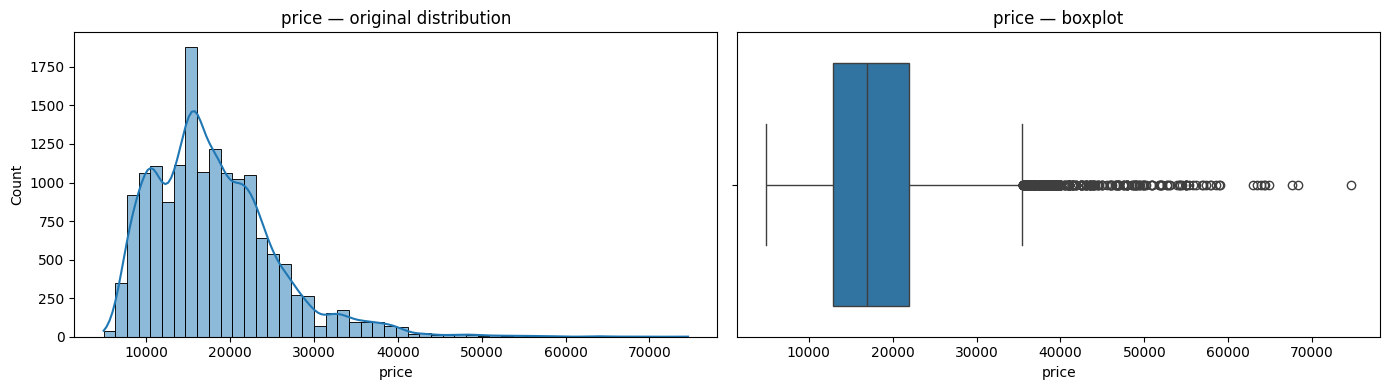

In [640]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df[target].dropna(), bins=50, kde=True, ax=axes[0])
axes[0].set_title(f'{target} — original distribution')

sns.boxplot(x=df[target].dropna(), ax=axes[1])
axes[1].set_title(f'{target} — boxplot')

plt.tight_layout()
plt.show()

**The target variable seems to be skewed. Perform suitable transformation on the target.**

Skewness before transformation: 1.2362
High skew detected — applying log transformation
Skewness after log: -0.0315


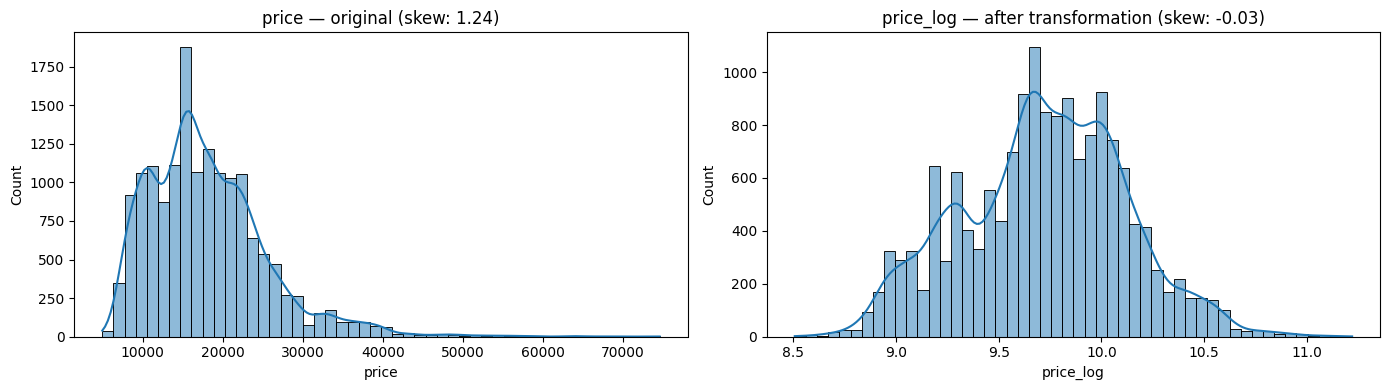

In [641]:
# Transform the target feature

target = 'price'
skew = df[target].skew()
print(f"Skewness before transformation: {skew:.4f}")

if abs(skew) > 1:
    df[f'{target}_log'] = np.log1p(df[target])
    new_skew = df[f'{target}_log'].skew()
    print(f"High skew detected — applying log transformation")
    print(f"Skewness after log: {new_skew:.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    sns.histplot(df[target], bins=50, kde=True, ax=axes[0])
    axes[0].set_title(f'{target} — original (skew: {skew:.2f})')

    sns.histplot(df[f'{target}_log'], bins=50, kde=True, ax=axes[1])
    axes[1].set_title(f'{target}_log — after transformation (skew: {new_skew:.2f})')

    plt.tight_layout()
    plt.show()

elif abs(skew) > 0.5:
    print(f"Moderate skew — consider sqrt transformation")
    df[f'{target}_sqrt'] = np.sqrt(df[target])
    print(f"Skewness after sqrt: {df[target + '_sqrt'].skew():.4f}")

else:
    print(f"Skewness is {skew:.4f} — approximately normal, no transformation needed")

### **2.2 Correlation analysis** <font color = red> [6 marks] </font>

#### **2.2.1** <font color =red> [3 marks] </font>
Plot the correlation map between features and target variable.

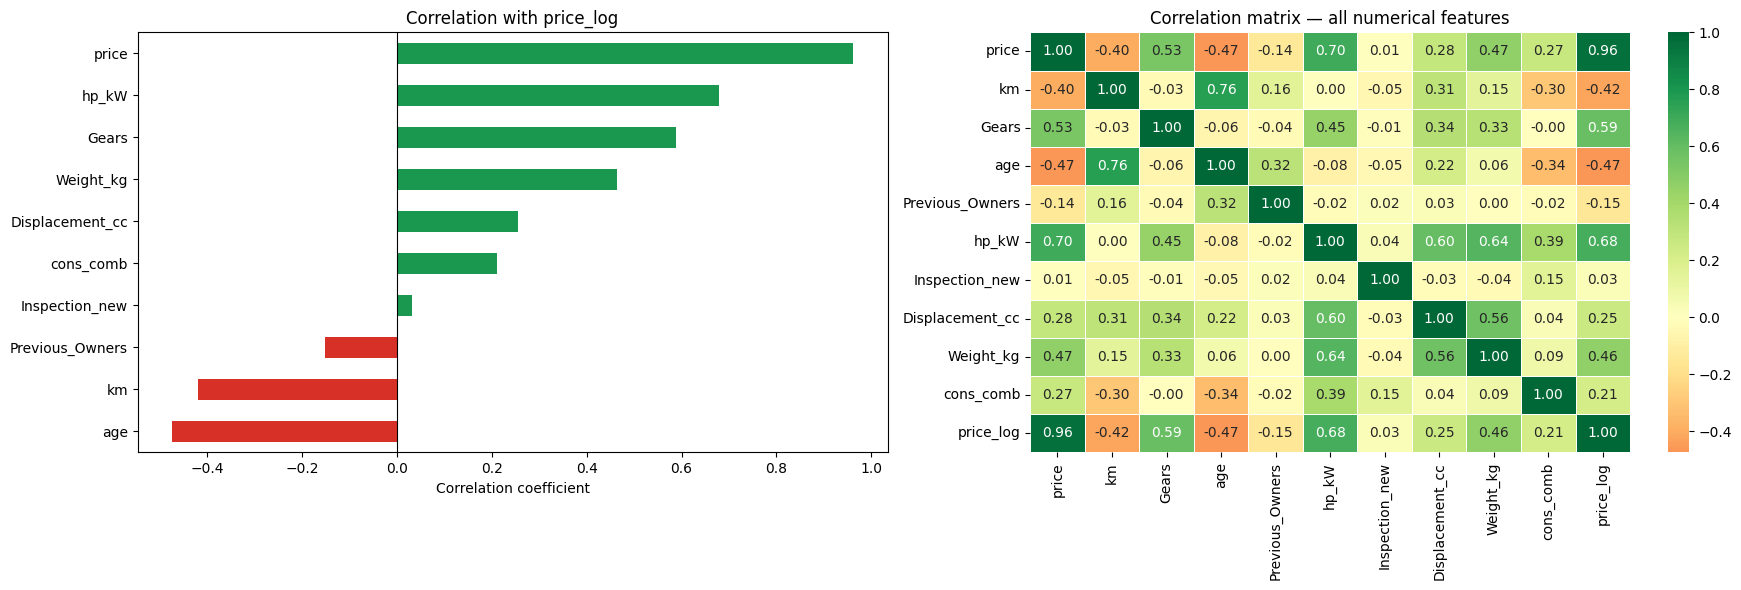

In [642]:
# Visualise correlation
# select numerical columns (again) including target
numerical_cols = df.select_dtypes(include='number').columns.tolist()

# correlation with target
corr_with_target = df[numerical_cols].corr()['price_log'].drop('price_log').sort_values()

# plot
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# bar plot — correlation with target
corr_with_target.plot(kind='barh', ax=axes[0], color=['#d73027' if x < 0 else '#1a9850' for x in corr_with_target])
axes[0].set_title('Correlation with price_log')
axes[0].set_xlabel('Correlation coefficient')
axes[0].axvline(x=0, color='black', linewidth=0.8)

# heatmap — full correlation matrix
sns.heatmap(
    df[numerical_cols].corr(),
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    ax=axes[1],
    linewidths=0.5
)
axes[1].set_title('Correlation matrix — all numerical features')

plt.tight_layout()
plt.show()


#### **2.2.2** <font color =red> [3 marks] </font>
Analyse correlation between categorical features and target variable.

In [643]:
# Comparing average values of target for different categories
target_col = 'price_log' if 'price_log' in df.columns else 'price'

multi_label_cols = ['Comfort_Convenience', 'Entertainment_Media', 'Extras', 'Safety_Security']
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
cat_cols = [col for col in cat_cols if col not in multi_label_cols]

print("SUMMARY: Mean price_log by category")
print("=" * 55)

for col in cat_cols:
    means = df.groupby(col)[target_col].mean().sort_values(ascending=False)
    highest_cat = means.index[0]
    lowest_cat  = means.index[-1]
    highest_val = means.iloc[0]
    lowest_val  = means.iloc[-1]
    diff        = highest_val - lowest_val

    print(f"\n{col}:")
    print(f"  Highest : {highest_cat:<25} (mean {target_col} = {highest_val:.2f})")
    print(f"  Lowest  : {lowest_cat:<25} (mean {target_col} = {lowest_val:.2f})")
    print(f"  Difference : {diff:.2f} {'<- strong effect' if diff > 0.3 else '← weak effect'}")


SUMMARY: Mean price_log by category

make_model:
  Highest : Renault Espace            (mean price_log = 10.27)
  Lowest  : Opel Corsa                (mean price_log = 9.28)
  Difference : 1.00 <- strong effect

body_type:
  Highest : Van                       (mean price_log = 10.29)
  Lowest  : Compact                   (mean price_log = 9.56)
  Difference : 0.74 <- strong effect

vat:
  Highest : VAT deductible            (mean price_log = 9.73)
  Lowest  : Price negotiable          (mean price_log = 9.56)
  Difference : 0.17 ← weak effect

Type:
  Highest : New                       (mean price_log = 9.94)
  Lowest  : Used                      (mean price_log = 9.63)
  Difference : 0.31 <- strong effect

Fuel:
  Highest : Diesel                    (mean price_log = 9.73)
  Lowest  : Other                     (mean price_log = 9.64)
  Difference : 0.10 ← weak effect

Paint_Type:
  Highest : Metallic                  (mean price_log = 9.73)
  Lowest  : Other                     (mean

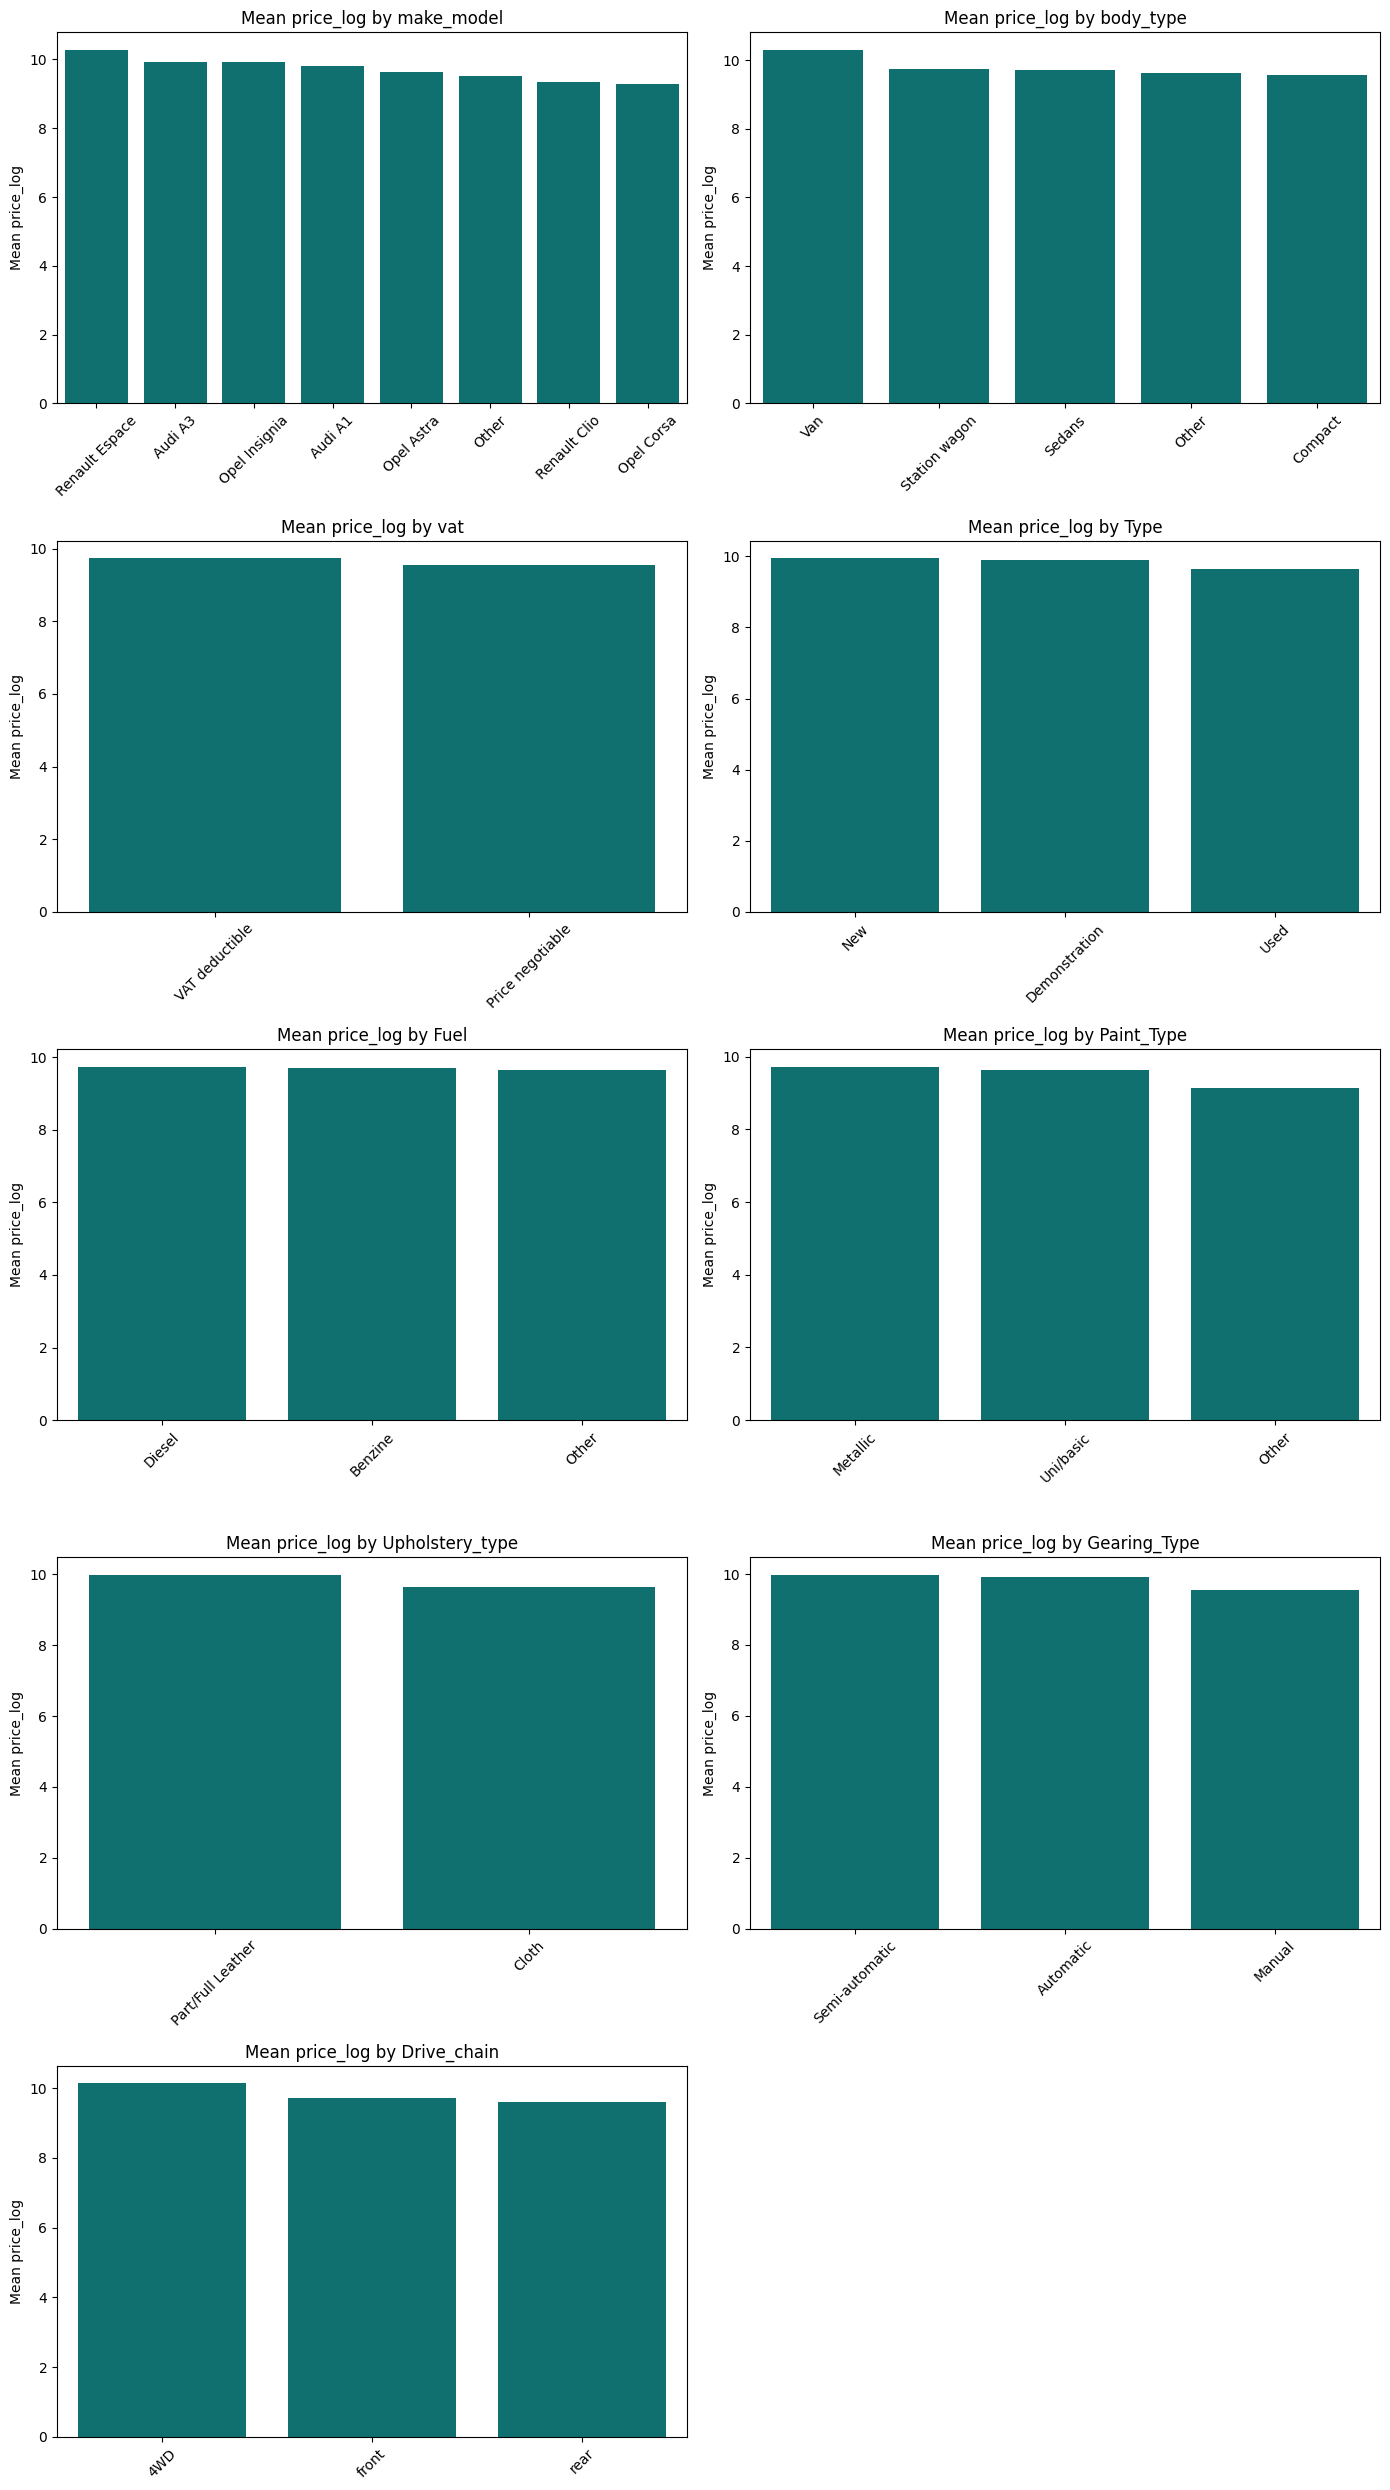

In [644]:
n = len(cat_cols)
cols = 2
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(14, rows * 5))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    mean_target = df.groupby(col)[target_col].mean().sort_values(ascending=False)
    sns.barplot(x=mean_target.index.astype(str), y=mean_target.values, color='teal', ax=axes[i])
    axes[i].set_title(f'Mean {target_col} by {col}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel(f'Mean {target_col}')
    axes[i].tick_params(axis='x', rotation=45)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

### **2.3 Outlier analysis** <font color = red> [5 marks] </font>

#### **2.3.1** <font color =red> [2 marks] </font>
Identify potential outliers in the data.

OUTLIER SUMMARY (IQR method)
         column     Q1      Q3     IQR  lower_bound  upper_bound  n_outliers   pct
 Inspection_new    0.0     0.0     0.0         0.00         0.00        3932 24.71
Previous_Owners    1.0     1.0     0.0         1.00         1.00        1757 11.04
             km 1920.5 46900.0 44979.5    -65548.75    114369.25         689  4.33
          hp_kW   66.0   103.0    37.0        10.50       158.50         361  2.27
          Gears    5.0     6.0     1.0         3.50         7.50         225  1.41
      cons_comb    4.1     5.4     1.3         2.15         7.35         125  0.79
      Weight_kg 1165.0  1472.0   307.0       704.50      1932.50          87  0.55
Displacement_cc 1229.0  1598.0   369.0       675.50      2151.50          21  0.13
            age    0.0     2.0     2.0        -3.00         5.00           0  0.00


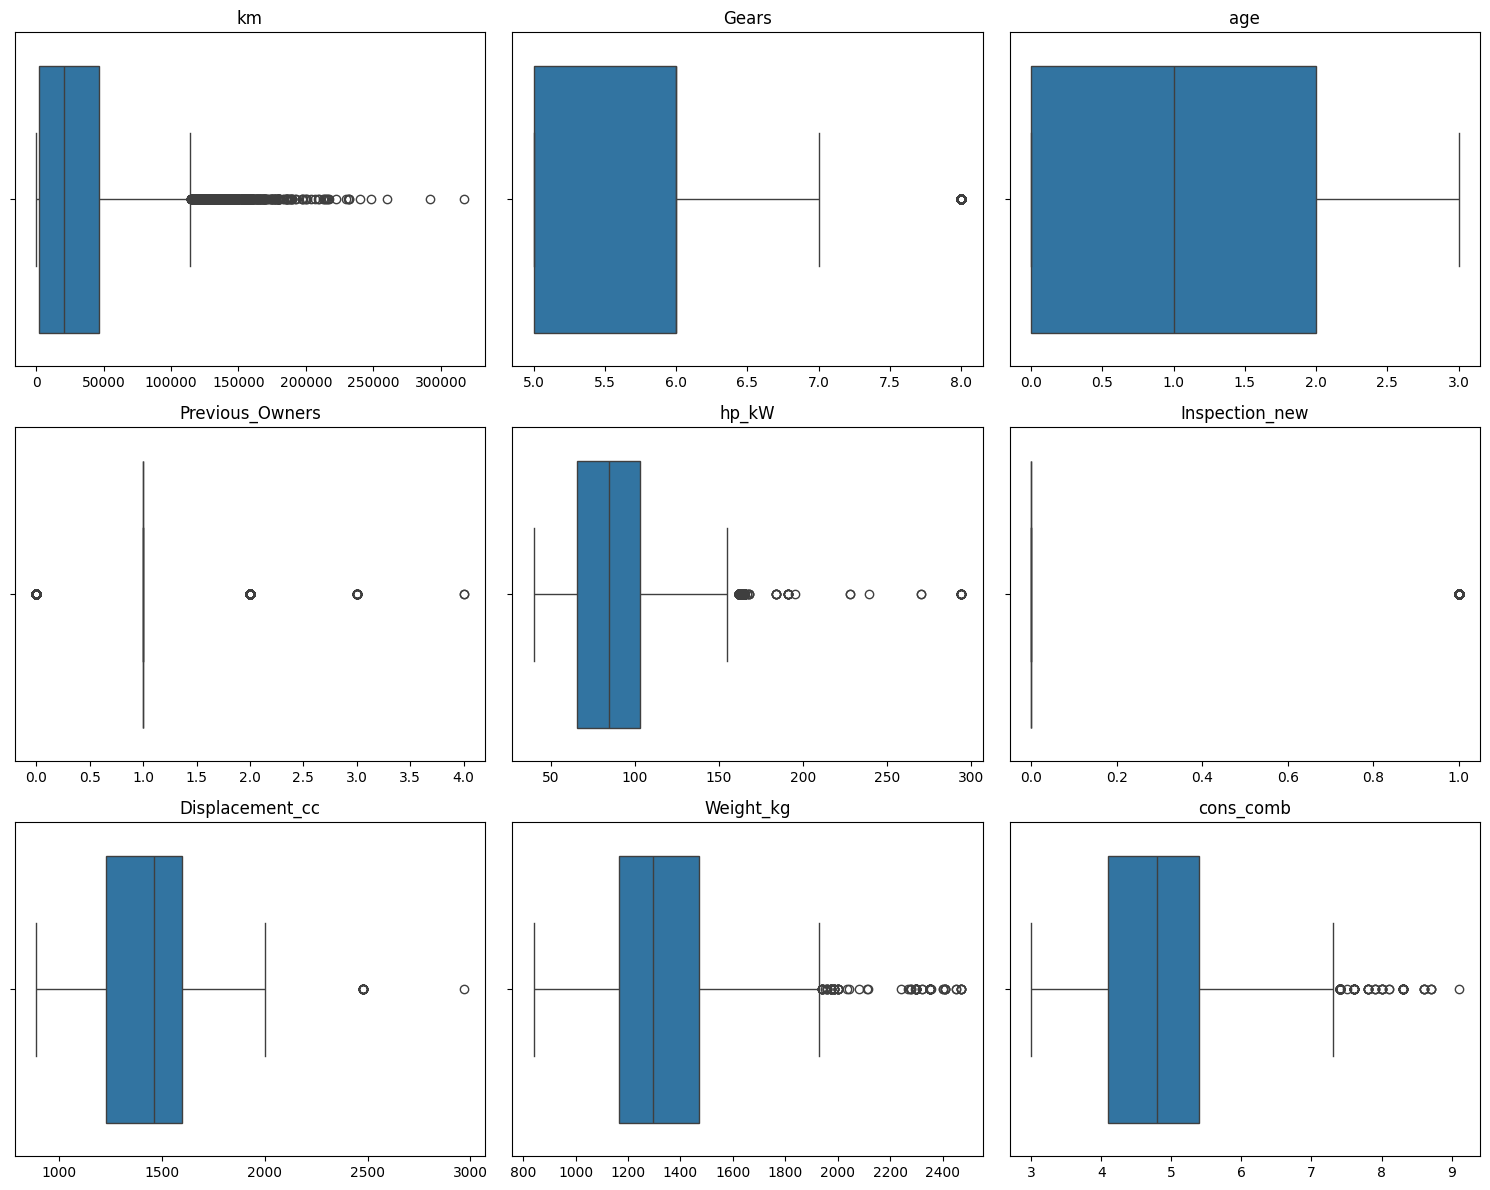

In [645]:
# Outliers present in each column

numerical_cols_current = df.select_dtypes(include='number').columns.tolist()
# remove target and log target from outlier analysis
cols_to_check = [col for col in numerical_cols_current if col not in ['price', 'price_log']]

#  Summary table
print("OUTLIER SUMMARY (IQR method)")
print("=" * 55)

outlier_summary = []
for col in cols_to_check:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    pct = n_outliers / len(df) * 100

    outlier_summary.append({
        'column'    : col,
        'Q1'        : round(Q1, 2),
        'Q3'        : round(Q3, 2),
        'IQR'       : round(IQR, 2),
        'lower_bound': round(lower, 2),
        'upper_bound': round(upper, 2),
        'n_outliers' : n_outliers,
        'pct'        : round(pct, 2)
    })

summary_df = pd.DataFrame(outlier_summary).sort_values('pct', ascending=False)
print(summary_df.to_string(index=False))

#  Boxplots
n = len(cols_to_check)
cols = 3
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 4))
axes = axes.flatten()

for i, col in enumerate(cols_to_check):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


In [646]:
for col in ['Inspection_new', 'Previous_Owners', "age"]:
    print(f"\n{col}:")
    print(df[col].value_counts().sort_index())


Inspection_new:
Inspection_new
0    11983
1     3932
Name: count, dtype: int64

Previous_Owners:
Previous_Owners
0.0      554
1.0    14158
2.0     1172
3.0       29
4.0        2
Name: count, dtype: int64

age:
age
0.0    4433
1.0    4526
2.0    3277
3.0    3679
Name: count, dtype: int64


## Outlier Analysis Summary

The IQR method was applied to all numerical columns to identify outliers.
The results are interpreted as follows:

### Columns where IQR method is not applicable
- **`Inspection_new`**: Binary column (0/1). IQR = 0, so any value of 1 is
flagged as outlier (24.71%). This is a false alarm — value counts confirm
a valid binary distribution (75.3% vs 24.7%). No action needed.

- **`Previous_Owners`**: Low cardinality column (values 0-4). IQR = 0,
causing the method to break down (11.04% flagged). Value counts confirm
a sensible distribution — majority have 1 previous owner, with a small
number having 2, 3, or 4. No action needed.

### Columns with real outliers requiring treatment
- **`km`**: 4.33% of values exceed the upper bound of 114,369 km.
These are genuinely high mileage cars that could distort the model.
Will be capped using IQR bounds (Winsorization).

- **`hp_kW`**: 2.27% of values exceed the upper bound of 158.5 kW.
These are high performance cars. Will be capped using IQR bounds.

### Columns with negligible outliers — no action needed
- **`Gears`** (1.41%), **`cons_comb`** (0.79%), **`Weight_kg`** (0.55%),
**`Displacement_cc`** (0.13%) all have under 1.5% outliers.
These likely represent legitimate high-end cars carrying real price signal.
Capping these would remove useful information from the model.

- **`age`**: No outliers detected.

### Action Plan
| Column | Action | Reason |
|---|---|---|
| `Inspection_new` | No action | Binary column, IQR not applicable |
| `Previous_Owners` | No action | Low cardinality, IQR not applicable |
| `km` | Cap (Winsorize) | 4.33% genuine high mileage outliers |
| `hp_kW` | Cap (Winsorize) | 2.27% genuine high performance outliers |
| `Gears` | No action | Under 1.5%, legitimate values |
| `cons_comb` | No action | Under 1.5%, legitimate values |
| `Weight_kg` | No action | Under 1.5%, legitimate values |
| `Displacement_cc` | No action | Under 1.5%, legitimate values |
| `age` | No action | No outliers detected |

#### **2.3.2** <font color =red> [3 marks] </font>
Handle the outliers suitably.

In [647]:
# Handle outliers - Winsorization
for col in ['km', 'hp_kW']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    before = df[col].describe()
    df[col] = df[col].clip(lower=lower, upper=upper)
    after = df[col].describe()

    print(f"\n{col} — clipped to [{lower:.1f}, {upper:.1f}]")
    print(f"  max before: {before['max']:.1f}  →  max after: {after['max']:.1f}")
    print(f"  min before: {before['min']:.1f}  →  min after: {after['min']:.1f}")



km — clipped to [-65548.8, 114369.2]
  max before: 317000.0  →  max after: 114369.2
  min before: 0.0  →  min after: 0.0

hp_kW — clipped to [10.5, 158.5]
  max before: 294.0  →  max after: 158.5
  min before: 40.0  →  min after: 40.0


### **2.4 Feature Engineering** <font color = red> [11 marks] </font>

#### **2.4.1**
Fix any redundant columns and create new ones if needed.

In [648]:
# Fix/create columns as needed
print(df.columns.tolist())
print(df.shape)

#  1. Create new features
# power to weight ratio — performance indicator
df['power_to_weight'] = df['hp_kW'] / df['Weight_kg']
print(f"Created power_to_weight — mean: {df['power_to_weight'].mean():.4f}")

# km per year — usage intensity, more informative than km alone
df['km_per_year'] = df['km'] / (df['age'] + 1)
print(f"Created km_per_year — mean: {df['km_per_year'].mean():.1f}")

#  2. Check for redundant columns
print(f"\nShape before: {df.shape}")
print(df.columns.tolist())


['make_model', 'body_type', 'price', 'vat', 'km', 'Type', 'Fuel', 'Gears', 'Comfort_Convenience', 'Entertainment_Media', 'Extras', 'Safety_Security', 'age', 'Previous_Owners', 'hp_kW', 'Inspection_new', 'Paint_Type', 'Upholstery_type', 'Gearing_Type', 'Displacement_cc', 'Weight_kg', 'Drive_chain', 'cons_comb', 'price_log']
(15915, 24)
Created power_to_weight — mean: 0.0655
Created km_per_year — mean: 10062.0

Shape before: (15915, 26)
['make_model', 'body_type', 'price', 'vat', 'km', 'Type', 'Fuel', 'Gears', 'Comfort_Convenience', 'Entertainment_Media', 'Extras', 'Safety_Security', 'age', 'Previous_Owners', 'hp_kW', 'Inspection_new', 'Paint_Type', 'Upholstery_type', 'Gearing_Type', 'Displacement_cc', 'Weight_kg', 'Drive_chain', 'cons_comb', 'price_log', 'power_to_weight', 'km_per_year']


# Current state of df:
|Type|Columns|
|-|-|
|Target| price, price_log|
|Numerical| km, age, Previous_Owners, hp_kW, Inspection_new, Displacement_cc, Weight_kg, cons_comb, Gears|
|Engineered numerical| power_to_weight, km_per_year|
| Categorical| make_model, body_type, Type, Fuel, Upholstery_type, Gearing_Type|
|Multi-label (to be handled) |Comfort_Convenience, Entertainment_Media, Extras, Safety_Security|

#### **2.4.2** <font color =red> [4 marks] </font>
Analysis and feature engineering on `['Comfort_Convenience', 'Entertainment_Media', 'Extras', 'Safety_Security']`.

These columns contains lists of features present. Decide on how to include these features in the predictors.

In [649]:
# Check unique values in each feature spec column

for col in ['Comfort_Convenience', 'Entertainment_Media', 'Extras', 'Safety_Security']:
    unique_features = df[col].str.split(',').explode().str.strip().unique()
    print(f"\n{col} — {len(unique_features)} unique features:")
    print(sorted(unique_features))


Comfort_Convenience — 38 unique features:
['Air conditioning', 'Air suspension', 'Armrest', 'Automatic climate control', 'Auxiliary heating', 'Cruise control', 'Electric Starter', 'Electric tailgate', 'Electrical side mirrors', 'Electrically adjustable seats', 'Electrically heated windshield', 'Heads-up display', 'Heated steering wheel', 'Hill Holder', 'Keyless central door lock', 'Leather seats', 'Leather steering wheel', 'Light sensor', 'Lumbar support', 'Massage seats', 'Multi-function steering wheel', 'Navigation system', 'Panorama roof', 'Park Distance Control', 'Parking assist system camera', 'Parking assist system self-steering', 'Parking assist system sensors front', 'Parking assist system sensors rear', 'Power windows', 'Rain sensor', 'Seat heating', 'Seat ventilation', 'Split rear seats', 'Start-stop system', 'Sunroof', 'Tinted windows', 'Wind deflector', 'Windshield']

Entertainment_Media — 10 unique features:
['Bluetooth', 'CD player', 'Digital radio', 'Hands-free equipmen

# Total unique features across all columns:

- Comfort_Convenience — 38
- Safety_Security — 29
- Extras — 17
- Entertainment_Media — 10

> Total = 94 binary columns if we binarize everything. That's manageable but we should remove low variance ones first.
  

In [650]:
# check presence rate of each feature in each column
for col in ['Comfort_Convenience', 'Entertainment_Media', 'Extras', 'Safety_Security']:
    print(f"\n{col}:")

    # get all individual features and their presence rate
    all_features = df[col].str.split(',').explode().str.strip()
    total_rows = len(df)
    presence = all_features.value_counts() / total_rows * 100

    print(f"  {'Feature':<45} {'Present %':>10}")
    print(f"  {'-'*55}")
    for feature, pct in presence.items():
        flag = ''
        if pct > 95:
            flag = ' ← drop (almost all cars have this)'
        elif pct < 5:
            flag = ' ← drop (almost no cars have this)'
        print(f"  {feature:<45} {pct:>9.1f}%{flag}")


Comfort_Convenience:
  Feature                                        Present %
  -------------------------------------------------------
  Air conditioning                                   94.8%
  Power windows                                      92.7%
  Electrical side mirrors                            78.5%
  Multi-function steering wheel                      73.8%
  Cruise control                                     73.0%
  Park Distance Control                              66.9%
  Parking assist system sensors rear                 63.4%
  Leather steering wheel                             61.2%
  Start-stop system                                  59.4%
  Automatic climate control                          57.8%
  Rain sensor                                        56.9%
  Navigation system                                  53.6%
  Light sensor                                       50.5%
  Armrest                                            47.8%
  Seat heating                     

# When to drop - rule that I will follow:

|Presence rate|Variance|Decision|
|-|-|-|
|100%|0%|Definitely drop — constant|
|> 95%|< 5%|Drop — near constant, adds noise|
|90-95%|5-10%|Borderline — judgement call|
|5-90%|Good|Keep — meaningful variance|
|< 5%|< 5%|Drop — too rare to learn from|

# Features to drop (based on above rule):

1. Comfort_Convenience — 12 features to drop (Parking assist self-steering,  Panorama roof, Heads-up display, Sunroof, Massage seats, Auxiliary heating, 3. Air suspension, Leather seats, Wind deflector, Windshield, Electric Starter + Air conditioning is 94.8% — borderline keep)
2. Entertainment_Media — 1 feature to drop (Television)
3. Extras — 9 features to drop
4. Safety_Security — 2 features to drop

No features above 95% — so nothing to drop from the top end except ABS at 94.4% and Air conditioning at 94.8% — borderline, keep them as they still have ~5% variance.

Out of these features, we will check the ones which are present in most of the cars or are absent from most of the cars. These kinds of features can be removed as they just increase the dimensionality without explaining the variance.

In [651]:
# Drop features from df

# Define low variance features to exclude per column
low_variance_features = {
    'Comfort_Convenience': [
        'Parking assist system self-steering', 'Panorama roof', 'Heads-up display',
        'Sunroof', 'Massage seats', 'Auxiliary heating', 'Air suspension',
        'Leather seats', 'Wind deflector', 'Windshield', 'Electric Starter'
    ],
    'Entertainment_Media': ['Television'],
    'Extras': [
        'Trailer hitch', 'Shift paddles', 'Cab or rented Car', 'Ski bag',
        'Winter tyres', 'Handicapped enabled', 'Tuned car', 'Sliding door',
        'Right hand drive'
    ],
    'Safety_Security': ['Driver drowsiness detection', 'Night view assist']
}

# Binarize — one column per feature, excluding low variance ones

all_new_cols = []

for col in ['Comfort_Convenience', 'Entertainment_Media', 'Extras', 'Safety_Security']:
    # split and strip
    features_split = df[col].fillna('').str.split(',').apply(
        lambda x: [i.strip() for i in x if i.strip() not in low_variance_features[col]]
    )

    mlb = MultiLabelBinarizer()
    binarized = pd.DataFrame(
        mlb.fit_transform(features_split),
        columns=[f"{col}__{f}" for f in mlb.classes_],
        index=df.index
    )

    df = pd.concat([df, binarized], axis=1)
    all_new_cols.extend(binarized.columns.tolist())
    print(f"{col}: {len(mlb.classes_)} features binarized")

# Drop original raw text columns
df.drop(columns=['Comfort_Convenience', 'Entertainment_Media',
                 'Extras', 'Safety_Security'], inplace=True)

print(f"\nTotal new binary columns: {len(all_new_cols)}")
print(f"Shape after binarization: {df.shape}")


Comfort_Convenience: 27 features binarized
Entertainment_Media: 9 features binarized
Extras: 8 features binarized
Safety_Security: 27 features binarized

Total new binary columns: 71
Shape after binarization: (15915, 93)


# Current State of df
- 15,915 rows × 93 columns

## Original columns remaining:  19
  - numerical:   km, age, Previous_Owners, hp_kW, Inspection_new,
                 Displacement_cc, Weight_kg, cons_comb, Gears
  - engineered:  power_to_weight, km_per_year
  - categorical: make_model, body_type, Type, Fuel,
                 Upholstery_type, Gearing_Type
  - target:      price, price_log

## New binary columns:          71
Examples:  `Comfort_Convenience__Air conditioning`, `Comfort_Convenience__Armrest`, `Extras__Roof rack ` etc
  - Comfort_Convenience__*   27
  - Entertainment_Media__*    9
  - Extras__*                 8
  - Safety_Security__*       27

In [652]:
feature_cols = [col for col in df.columns if '__' in col]
correlation = df[feature_cols].corrwith(df['price']).abs()
top_features = correlation.sort_values(ascending=False).head(10)
print(top_features)

Safety_Security__LED Headlights                             0.436199
Comfort_Convenience__Automatic climate control              0.414838
Safety_Security__Lane departure warning system              0.378763
Safety_Security__Blind spot monitor                         0.377029
Comfort_Convenience__Park Distance Control                  0.371756
Safety_Security__Traffic sign recognition                   0.354418
Comfort_Convenience__Rain sensor                            0.351564
Safety_Security__Emergency brake assistant                  0.344904
Comfort_Convenience__Parking assist system sensors front    0.332329
Comfort_Convenience__Navigation system                      0.329263
dtype: float64


#### **2.4.3** <font color =red> [3 marks] </font>
Perform feature encoding.

In [653]:
# check remaining categorical columns
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print("Categorical columns to encode:", cat_cols)
print(f"Shape before encoding: {df.shape}")

Categorical columns to encode: ['make_model', 'body_type', 'vat', 'Type', 'Fuel', 'Paint_Type', 'Upholstery_type', 'Gearing_Type', 'Drive_chain']
Shape before encoding: (15915, 93)


In [654]:
# Encode features
# Ordinal encoding
# Type — New > Demonstration > Used
type_order = {'New': 2, 'Demonstration': 1, 'Used': 0}
df['Type'] = df['Type'].map(type_order)
print(f"\nType encoded: {df['Type'].value_counts().to_dict()}")



Type encoded: {0: 11095, 2: 3013, 1: 1807}


In [655]:
# Gearing_Type — Semi-automatic > Automatic > Manual
gearing_order = {'Semi-automatic': 2, 'Automatic': 1, 'Manual': 0}
df['Gearing_Type'] = df['Gearing_Type'].map(gearing_order)
print(f"Gearing_Type encoded: {df['Gearing_Type'].value_counts().to_dict()}")

Gearing_Type encoded: {0: 8149, 1: 7297, 2: 469}


In [656]:
# Upholstery_type — binary
upholstery_order = {'Part/Full Leather': 1, 'Cloth': 0}
df['Upholstery_type'] = df['Upholstery_type'].map(upholstery_order)
print(f"Upholstery_type encoded: {df['Upholstery_type'].value_counts().to_dict()}")

Upholstery_type encoded: {0: 12234, 1: 3681}


In [657]:
# One-hot encoding
ohe_cols = ['Fuel', 'body_type', 'make_model', 'vat', 'Paint_Type', 'Drive_chain']
df = pd.get_dummies(df, columns=ohe_cols, drop_first=True)
print(f"\nOne-hot encoded: {ohe_cols}")


One-hot encoded: ['Fuel', 'body_type', 'make_model', 'vat', 'Paint_Type', 'Drive_chain']


In [658]:
print(f"\nShape after encoding: {df.shape}")
print(f"Remaining object columns: {df.select_dtypes(include='object').columns.tolist()}")


Shape after encoding: (15915, 105)
Remaining object columns: []


#### **2.4.4** <font color =red> [2 marks] </font>
Split the data into training and testing sets.

In [659]:
# Split data


#  1. Define features and target
X = df.drop(columns=['price', 'price_log'])
y = df['price_log']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

#  2. Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nX_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")




X shape: (15915, 103)
y shape: (15915,)

X_train: (12732, 103)
X_test:  (3183, 103)
y_train: (12732,)
y_test:  (3183,)


#### **2.4.5** <font color =red> [2 marks] </font>
Scale the features.

In [660]:
# 3. Scale features
# fit scaler on train only — apply to both
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# demonstrate why StandardScaler is preferred over MinMaxScaler
mm_scaler = MinMaxScaler()
X_train_mm = mm_scaler.fit_transform(X_train)

print("Effect of outliers on scaling methods:")
print("=" * 55)
for col in ['km', 'hp_kW']:
    col_idx = list(X_train.columns).index(col)
    std_75 = X_train_scaled[:, col_idx][X_train[col] <= X_train[col].quantile(0.75)].max()
    mm_75  = X_train_mm[:, col_idx][X_train[col] <= X_train[col].quantile(0.75)].max()
    print(f"\n{col}:")
    print(f"  MinMaxScaler   — 75% of values compressed into 0.00 to {mm_75:.2f}")
    print(f"  StandardScaler — 75% of values spread  across -2.00 to {std_75:.2f}")

# clean up — mm_scaler not needed going forward
del mm_scaler, X_train_mm


Effect of outliers on scaling methods:

km:
  MinMaxScaler   — 75% of values compressed into 0.00 to 0.41
  StandardScaler — 75% of values spread  across -2.00 to 0.48

hp_kW:
  MinMaxScaler   — 75% of values compressed into 0.00 to 0.53
  StandardScaler — 75% of values spread  across -2.00 to 0.58


In [661]:
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

## **3 Linear Regression Models** <font color =red> [35 marks] </font>


### **3.1 Baseline Linear Regression Model** <font color =red> [10 marks] </font>

#### **3.1.1** <font color =red> [5 marks] </font>
Build and fit a basic linear regression model. Perform evaluation using suitable metrics.

In [662]:
# Initialise and train model
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

#  Predictions
y_pred_train = lr.predict(X_train_scaled)
y_pred_test  = lr.predict(X_test_scaled)

In [663]:
print("Sample predictions vs actual (train):")
display(pd.DataFrame({
    'Actual Train'   : np.round(y_train.values, 2),
    'Predicted Train': np.round(y_pred_train, 2),
    'Difference'     : np.round(y_train.values - y_pred_train, 2)
}, index=y_train.index).sample(5, random_state=0))

print("\nSample predictions vs actual (test):")
display(pd.DataFrame({
    'Actual Test'   : np.round(y_test.values, 2),
    'Predicted Test': np.round(y_pred_test, 2),
    'Difference'    : np.round(y_test.values - y_pred_test, 2)
}, index=y_test.index).sample(5, random_state=0))

Sample predictions vs actual (train):


,Actual Train,Predicted Train,Difference
7704,10.19,10.13,0.06
1605,10.04,10.05,-0.01
14322,9.21,9.22,-0.01
13630,8.97,8.97,0.01
13922,9.14,9.00,0.14



Sample predictions vs actual (test):


,Actual Test,Predicted Test,Difference
13868,9.83,9.96,-0.14
8887,9.62,9.36,0.26
10255,9.28,9.34,-0.06
11766,9.72,9.82,-0.10
5489,10.08,10.05,0.03


In [664]:
# Evaluate the model's performance
def evaluate_model(y_true, y_pred, label):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"\n{label}")
    print(f"  R²   : {r2:.4f}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  MAE  : {mae:.4f}")
    return {'r2': r2, 'rmse': rmse, 'mae': mae}

print("LINEAR REGRESSION — Evaluation")
print("=" * 40)
train_metrics = evaluate_model(y_train, y_pred_train, "Train")
test_metrics  = evaluate_model(y_test,  y_pred_test,  "Test")

# Overfitting check
print(f"\nOverfitting check:")
print(f"  R² Train : {train_metrics['r2']:.4f}")
print(f"  R² Test  : {test_metrics['r2']:.4f}")
print(f"  Gap      : {train_metrics['r2'] - test_metrics['r2']:.4f}")

if train_metrics['r2'] - test_metrics['r2'] > 0.05:
    print("  ⚠ Significant gap — model may be overfitting")
else:
    print("  ✓ Small gap — model generalises well")


LINEAR REGRESSION — Evaluation

Train
  R²   : 0.9275
  RMSE : 0.1071
  MAE  : 0.0785

Test
  R²   : 0.9310
  RMSE : 0.1050
  MAE  : 0.0782

Overfitting check:
  R² Train : 0.9275
  R² Test  : 0.9310
  Gap      : -0.0035
  ✓ Small gap — model generalises well


#### **3.1.2** <font color =red> [5 marks] </font>
Analyse residuals and check other assumptions of linear regression.

Check for linearity by analysing residuals vs predicted values

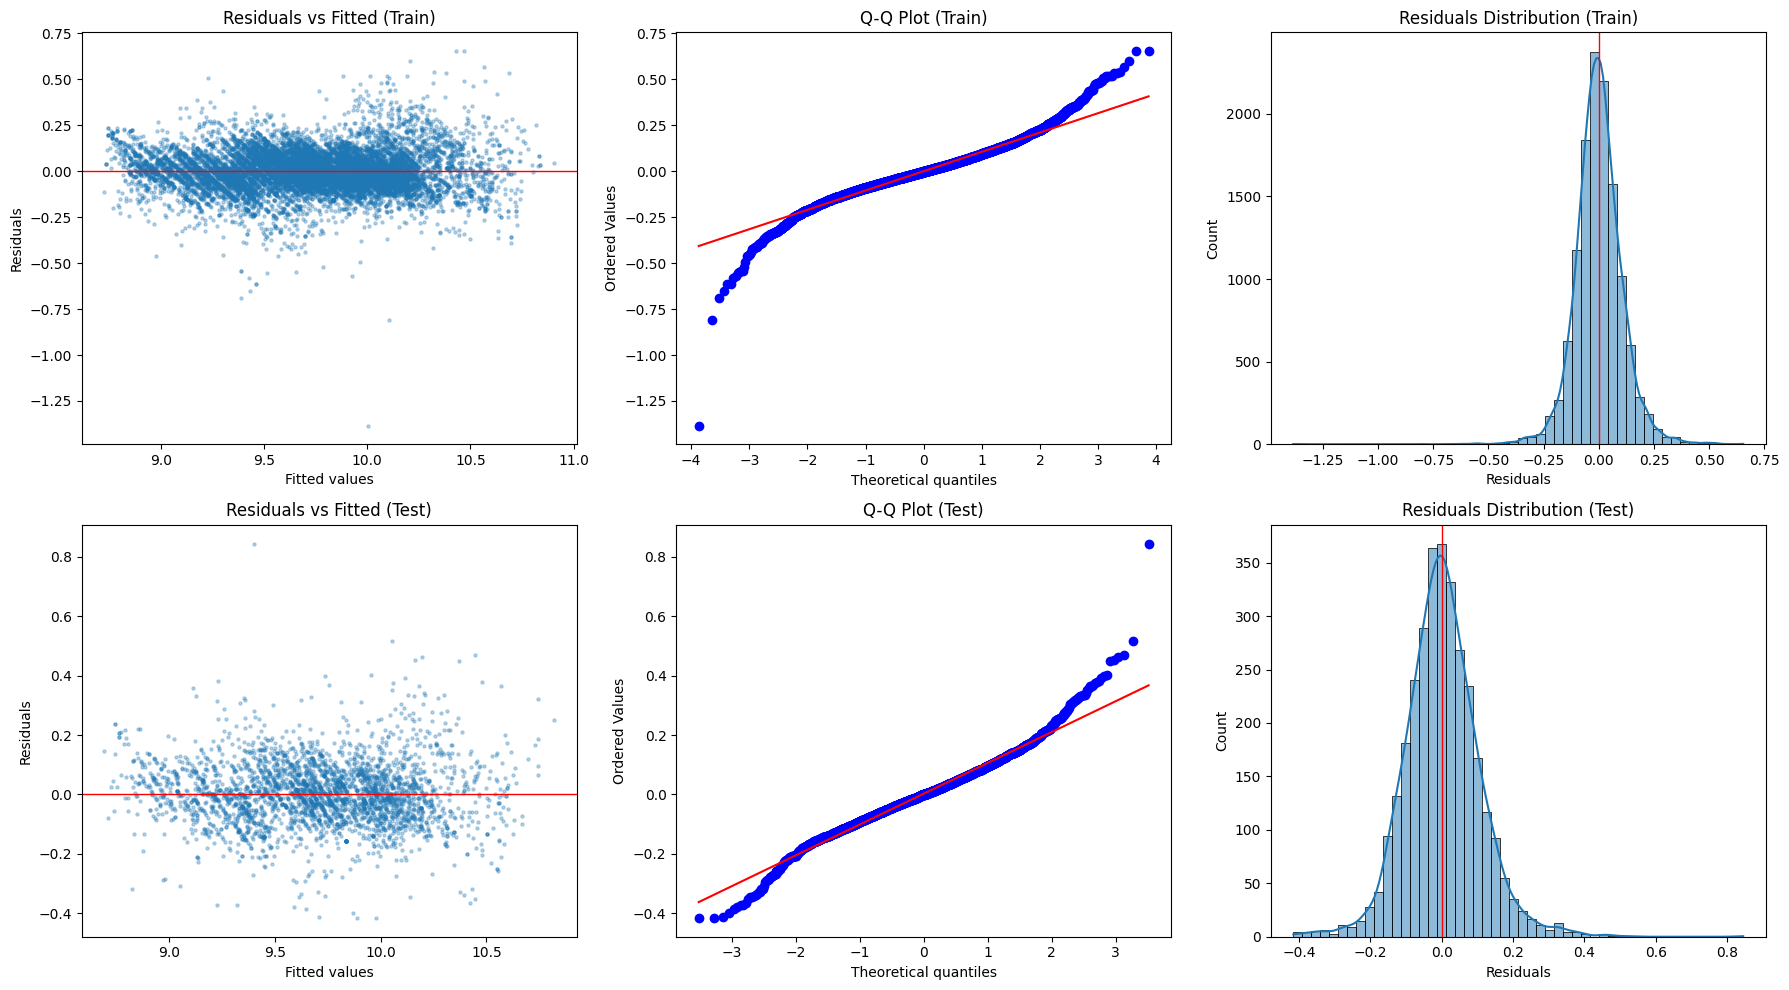

Residuals Summary

Train:
  Mean   : -0.0000  (should be ~0)
  Std    : 0.1071
  Skew   : -0.0672  (should be ~0)
  Kurt   : 5.0663  (should be ~0)

Test:
  Mean   : 0.0024  (should be ~0)
  Std    : 0.1050
  Skew   : 0.3792  (should be ~0)
  Kurt   : 2.8924  (should be ~0)


In [665]:
# Linearity check: Plot residuals vs fitted values

#  Residuals
residuals_train = y_train.values - y_pred_train
residuals_test  = y_test.values  - y_pred_test

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

#  1. Residuals vs Fitted (Linearity check)
axes[0][0].scatter(y_pred_train, residuals_train, alpha=0.3, s=5)
axes[0][0].axhline(y=0, color='red', linewidth=1)
axes[0][0].set_title('Residuals vs Fitted (Train)')
axes[0][0].set_xlabel('Fitted values')
axes[0][0].set_ylabel('Residuals')

axes[1][0].scatter(y_pred_test, residuals_test, alpha=0.3, s=5)
axes[1][0].axhline(y=0, color='red', linewidth=1)
axes[1][0].set_title('Residuals vs Fitted (Test)')
axes[1][0].set_xlabel('Fitted values')
axes[1][0].set_ylabel('Residuals')

#  2. Normal Q-Q Plot (Normality check)
stats.probplot(residuals_train, dist='norm', plot=axes[0][1])
axes[0][1].set_title('Q-Q Plot (Train)')

stats.probplot(residuals_test, dist='norm', plot=axes[1][1])
axes[1][1].set_title('Q-Q Plot (Test)')

#  3. Residuals Distribution (Normality check)
sns.histplot(residuals_train, bins=50, kde=True, ax=axes[0][2])
axes[0][2].axvline(x=0, color='red', linewidth=1)
axes[0][2].set_title('Residuals Distribution (Train)')
axes[0][2].set_xlabel('Residuals')

sns.histplot(residuals_test, bins=50, kde=True, ax=axes[1][2])
axes[1][2].axvline(x=0, color='red', linewidth=1)
axes[1][2].set_title('Residuals Distribution (Test)')
axes[1][2].set_xlabel('Residuals')

plt.tight_layout()
plt.show()

#  Summary statistics
print("Residuals Summary")
print("=" * 40)
for label, residuals in [("Train", residuals_train), ("Test", residuals_test)]:
    print(f"\n{label}:")
    print(f"  Mean   : {residuals.mean():.4f}  (should be ~0)")
    print(f"  Std    : {residuals.std():.4f}")
    print(f"  Skew   : {pd.Series(residuals).skew():.4f}  (should be ~0)")
    print(f"  Kurt   : {pd.Series(residuals).kurt():.4f}  (should be ~0)")



## 1. Linearity & Homoscedasticity — Residuals vs Fitted
The residuals vs fitted plot actually shows a reasonably even horizontal band across most of the range. Overall the homoscedasticity assumption is reasonably well satisfied — no strong funnel shape, no systematic pattern.

## 2. Normality — Q-Q Plot
Both plots follow the diagonal line well in the middle range but deviate at the tails — points curve away at both ends. This is classic heavy-tailed behaviour meaning extreme residuals are larger than a perfect normal distribution would predict.
Confirmed by kurtosis:
```
Train Kurt = 5.13  ← heavy tails (normal = 0)
Test  Kurt = 2.49  ← moderate heavy tails
```
## 3.Normality — Residuals Distribution
Both distributions are centred at 0 — confirmed by:
```
Train Mean = -0.0000  
Test  Mean =  0.0025
```


Check normality in residual distribution

## The three plots are already shown above. Plotting Residual Dist and Q-Q plot again

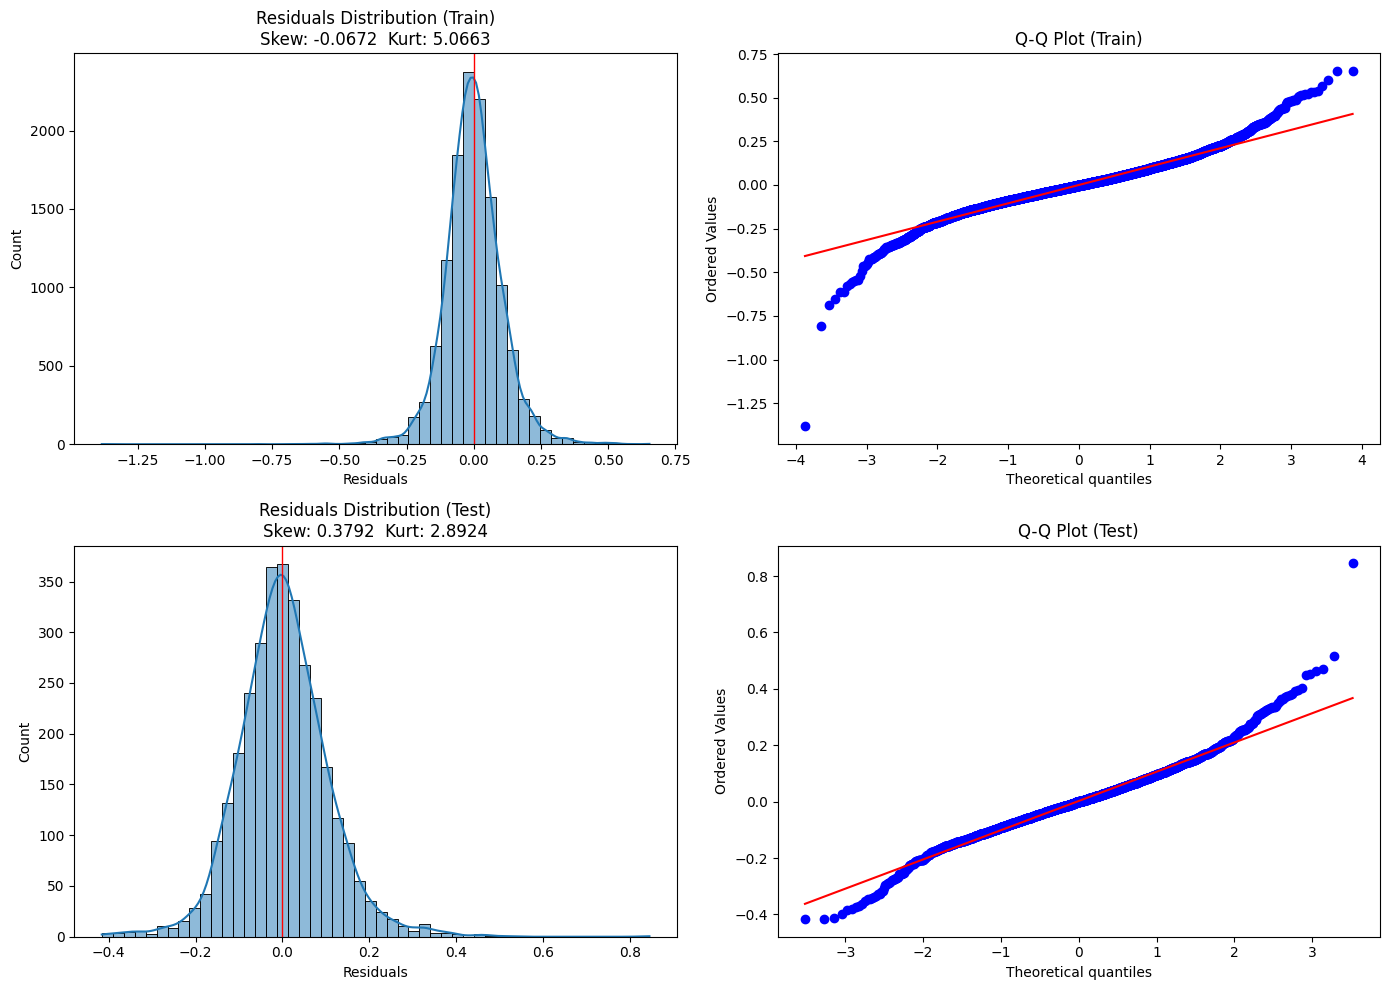

In [666]:
# Check the normality of residuals by plotting their distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

#  Train
sns.histplot(residuals_train, bins=50, kde=True, ax=axes[0][0])
axes[0][0].axvline(x=0, color='red', linewidth=1)
axes[0][0].set_title(f'Residuals Distribution (Train)\nSkew: {pd.Series(residuals_train).skew():.4f}  Kurt: {pd.Series(residuals_train).kurt():.4f}')
axes[0][0].set_xlabel('Residuals')

stats.probplot(residuals_train, dist='norm', plot=axes[0][1])
axes[0][1].set_title('Q-Q Plot (Train)')

#  Test
sns.histplot(residuals_test, bins=50, kde=True, ax=axes[1][0])
axes[1][0].axvline(x=0, color='red', linewidth=1)
axes[1][0].set_title(f'Residuals Distribution (Test)\nSkew: {pd.Series(residuals_test).skew():.4f}  Kurt: {pd.Series(residuals_test).kurt():.4f}')
axes[1][0].set_xlabel('Residuals')

stats.probplot(residuals_test, dist='norm', plot=axes[1][1])
axes[1][1].set_title('Q-Q Plot (Test)')

plt.tight_layout()
plt.show()


Check multicollinearity using Variance Inflation Factor (VIF) and handle features with high VIF.

In [667]:
# Check for multicollinearity and handle

# Compute VIF for a DataFrame
def compute_vif(X_df):
    vif_data = pd.DataFrame()
    vif_data['feature'] = X_df.columns
    vif_data['VIF'] = [
        variance_inflation_factor(X_df.values, i)
        for i in range(X_df.shape[1])
    ]
    return vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)


# Iteratively remove high-VIF features
def iterative_vif_removal(X_df, threshold=10.0, protected_features=None, verbose=True):
    X_reduced = X_df.copy()

    # allow protecting important features from being dropped automatically
    if protected_features is None:
        protected_features = []

    removed_features = []
    step = 1

    if verbose:
        print(f"Iterative VIF removal (threshold = {threshold})")
        print("=" * 55)

    while True:
        vif_df = compute_vif(X_reduced)
        max_vif = vif_df.iloc[0]['VIF']

        # Stop when all VIF values are under threshold
        if max_vif <= threshold:
            if verbose:
                print(f"\nStep {step}: All VIF scores below {threshold} — stopping")
            break

        # find the worst removable feature
        feature_to_drop = None

        for _, row in vif_df.iterrows():
            candidate = row['feature']
            candidate_vif = row['VIF']

            if candidate_vif <= threshold:
                break

            if candidate not in protected_features:
                feature_to_drop = candidate
                break

        # if only protected features remain above threshold, stop safely
        if feature_to_drop is None:
            if verbose:
                print("\nNo removable features remain above threshold.")
                print("Stopping because remaining high-VIF features are protected.")
            break

        if verbose:
            current_vif = vif_df.loc[vif_df['feature'] == feature_to_drop, 'VIF'].values[0]
            print(f"\nStep {step}: Dropping '{feature_to_drop}' — VIF = {current_vif:.2f}")

        X_reduced = X_reduced.drop(columns=[feature_to_drop])
        removed_features.append(feature_to_drop)
        step += 1

    final_vif_df = compute_vif(X_reduced)

    return X_reduced, removed_features, final_vif_df


# --------------------------------------------------
# Apply iterative VIF removal
# --------------------------------------------------

# Protect key engineered / important predictors so VIF does not drop them blindly.
protected_features = ['hp_kW', 'km_per_year'] + [
    col for col in X_train_scaled.columns if col.startswith('make_model_')
]

X_train_scaled_vif, removed_features, final_vif_df = iterative_vif_removal(
    X_train_scaled,
    threshold=10.0,
    protected_features=protected_features,
    verbose=True
)

# Changed: align test set using the final remaining columns
X_test_scaled_vif = X_test_scaled[X_train_scaled_vif.columns].copy()


# --------------------------------------------------
# Reporting
# --------------------------------------------------
print("\nFeatures removed:")
print(removed_features)

print(f"\nShape before VIF: {X_train_scaled.shape}")
print(f"Shape after VIF : {X_train_scaled_vif.shape}")

print("\nFinal VIF Scores")
print("=" * 55)
print(final_vif_df.to_string(index=False))

print(f"\nSummary after VIF reduction:")
print(f"  VIF > 10  (severe)   : {(final_vif_df['VIF'] > 10).sum()} features")
print(f"  VIF 5-10  (moderate) : {((final_vif_df['VIF'] > 5) & (final_vif_df['VIF'] <= 10)).sum()} features")
print(f"  VIF < 5   (fine)     : {(final_vif_df['VIF'] <= 5).sum()} features")


# --------------------------------------------------
# inspect top remaining VIF values
# --------------------------------------------------
# print("\nTop remaining VIF values:")
# display(final_vif_df.head(15))

Iterative VIF removal (threshold = 10.0)

Step 1: Dropping 'power_to_weight' — VIF = 91.12

Step 2: Dropping 'km' — VIF = 20.73

No removable features remain above threshold.
Stopping because remaining high-VIF features are protected.

Features removed:
['power_to_weight', 'km']

Shape before VIF: (12732, 103)
Shape after VIF : (12732, 101)

Final VIF Scores
                                                 feature       VIF
                               make_model_Renault Espace 10.198923
                                                   hp_kW  8.536177
                                           body_type_Van  6.858337
                                make_model_Opel Insignia  6.833274
                                         Displacement_cc  6.817262
                                             Fuel_Diesel  6.811694
                                   make_model_Opel Corsa  5.220948
 Comfort_Convenience__Parking assist system sensors rear  4.970139
                                    

### **3.2 Ridge Regression Implementation** <font color =red> [10 marks] </font>

#### **3.2.1** <font color =red> [2 marks] </font>
Define a list of random alpha values

In [668]:
# List of alphas to tune for Ridge regularisation
# param_grid = {'alpha': np.linspace(0.0001, 1000, 100)}
param_grid = {'alpha': np.logspace(-3, 3, 100)} #covers 0.001 to 1000.


#### **3.2.2** <font color =red> [4 marks] </font>
Apply Ridge Regularisation and find the best value of alpha from the list

In [669]:
# Applying Ridge regression
ridge = Ridge()

# GridSearchCV for tuning Ridge hyperparameters
model_cv_ridge = GridSearchCV(estimator=ridge, param_grid = param_grid,
                        scoring = "neg_mean_absolute_error",
                        cv=5, n_jobs=-1, return_train_score=True, verbose=1)

model_cv_ridge.fit(X_train_scaled, y_train)

print(model_cv_ridge.best_estimator_.n_iter_)


Fitting 5 folds for each of 100 candidates, totalling 500 fits
None


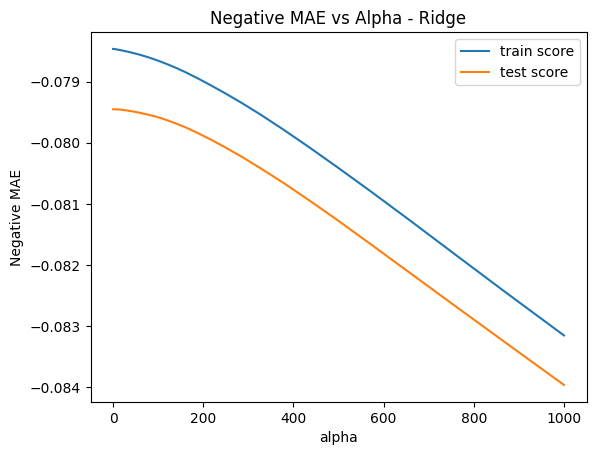

In [671]:
# Plot train and test scores against alpha
def plot_train_vs_test_alpha(model_cv, title="Negative MAE vs Alpha"): # Plot train and test scores against alpha
    cv_results = pd.DataFrame(model_cv.cv_results_)

    # Plot train and test scores against alpha
    plt.plot(cv_results['param_alpha'], cv_results['mean_train_score'])
    plt.plot(cv_results['param_alpha'], cv_results['mean_test_score'])
    plt.xlabel('alpha')
    plt.ylabel('Negative MAE')

    plt.title(title)
    plt.legend(['train score', 'test score'], loc='upper right')
    plt.show()

plot_train_vs_test_alpha(model_cv_ridge, "Negative MAE vs Alpha - Ridge")

Text(0.5, 1.0, 'Feature Importance (Ridge Coefficients)')

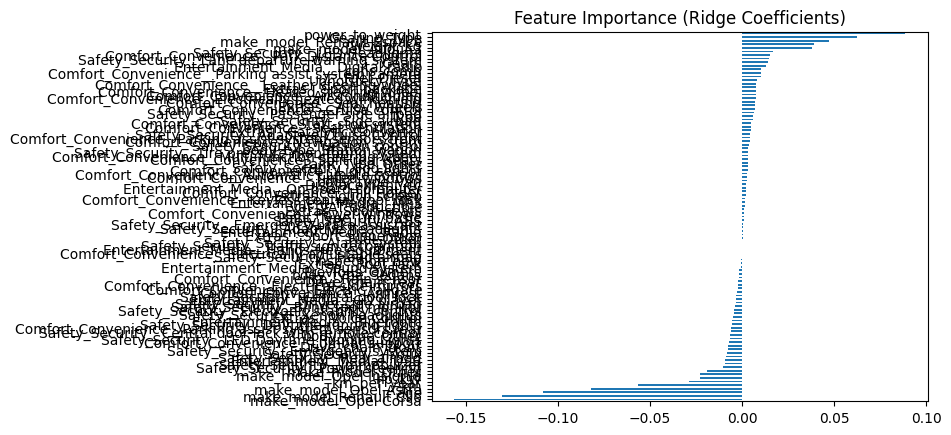

In [672]:
# Look at the coefficients of your best model
importance = pd.Series(model_cv_ridge.best_estimator_.coef_, index=X_train.columns)
importance.sort_values().plot(kind='barh')
plt.title("Feature Importance (Ridge Coefficients)")

Find the best alpha value.

In [673]:
# Best alpha value
best_ridge_alpha = model_cv_ridge.best_params_['alpha']
print(f"Best alpha: {best_ridge_alpha}")

# Best score (negative MAE)
best_score = model_cv_ridge.best_score_
print(f"Best negative MAE: {best_score}")

Best alpha: 3.2745491628777286
Best negative MAE: -0.07945188387898619


We will get some best value of alpha above. This however is not the most accurate value but the best value from the given list. Now we have a rough estimate of the range that best alpha falls in. Let us do another iteration over the values in a smaller range.

#### **3.2.3** <font color =red> [4 marks] </font>
Fine tune by taking a closer range of alpha based on the previous result.

In [674]:
# Take a smaller range of alpha to test
# Fine-tuning range centered around your previous best (3.27)
param_grid = {'alpha': np.linspace(0.01, 15, 100)}


In [675]:
# Applying Ridge regression
ridge = Ridge()
model_cv_ridge = GridSearchCV(estimator=ridge,
                        param_grid=param_grid,
                        scoring='neg_mean_absolute_error',
                        cv=5,
                        return_train_score=True, verbose=1)
model_cv_ridge.fit(X_train_scaled, y_train)

print(model_cv_ridge.best_estimator_.n_iter_)


Fitting 5 folds for each of 100 candidates, totalling 500 fits
None


Plot the error-alpha graph again and find the actual optimal value for alpha.

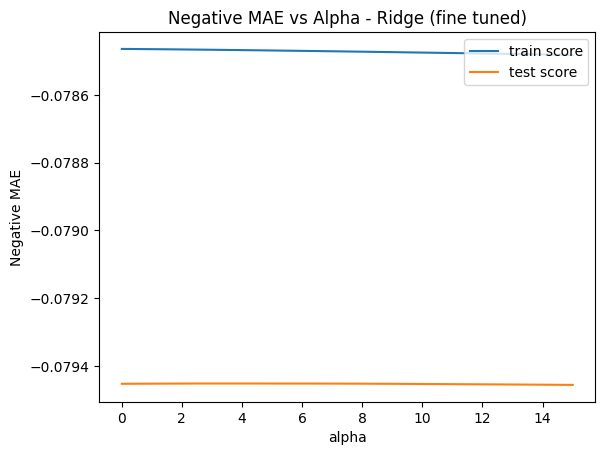

Best Alpha: 3.1896969696969695
Best Negative MAE: -0.0794518835250631


In [677]:
# Plot train and test scores against alpha

# Plot train and test scores against alpha
plot_train_vs_test_alpha(model_cv_ridge, "Negative MAE vs Alpha - Ridge (fine tuned)")

# Best alpha value
print(f"Best Alpha: {model_cv_ridge.best_params_['alpha']}")

# Best score (negative MAE)
print(f"Best Negative MAE: {model_cv_ridge.best_score_}")



In [678]:
# Set best alpha for Ridge regression
best_alpha = model_cv_ridge.best_params_['alpha']
ridge_final = Ridge(alpha=best_alpha)

# Fit the Ridge model to get the coefficients
ridge_final.fit(X_train_scaled, y_train)



Ridge(alpha=np.float64(3.1896969696969695))

In [699]:
# Show the coefficients for each feature
coeff_df_ridge = pd.DataFrame({'Feature': X_train.columns, 'Coefficient': ridge_final.coef_})
print(coeff_df_ridge.sort_values(by='Coefficient', ascending=False))


                      Feature  Coefficient
12            power_to_weight     0.088552
8                Gearing_Type     0.062171
97  make_model_Renault Espace     0.047098
10                  Weight_kg     0.038956
91         make_model_Audi A3     0.037799
..                        ...          ...
0                          km    -0.056714
92      make_model_Opel Astra    -0.082026
3                         age    -0.108022
96    make_model_Renault Clio    -0.130669
93      make_model_Opel Corsa    -0.156328

[103 rows x 2 columns]


In [680]:

# Evaluate the Ridge model on the test data
from sklearn.metrics import mean_absolute_error, r2_score

y_pred_ridge = ridge_final.predict(X_test_scaled)

print(f"Final Ridge Test MAE: {mean_absolute_error(y_test, y_pred_ridge)}")
print(f"Final Ridge Test R2: {r2_score(y_test, y_pred_ridge)}")


Final Ridge Test MAE: 0.07818459453798182
Final Ridge Test R2: 0.9310223870551001


|Metric|Conclusion|
|-|-|
|Alpha Sensitivity|Very Low (Flat Error Curve)|
|Overfitting|Negligible (Train/Test scores are very close)|
|Multicollinearity|Managed well by the initial feature selection/scaling|
|Recommendation|Use Lasso next to see if we can get the same 0.93 R2 using fewer than 103 features|

### **3.3 Lasso Regression Implementation** <font color =red> [10 marks] </font>

#### **3.3.1** <font color =red> [2 marks] </font>
Define a list of random alpha values

In [681]:
# List of alphas to tune for Lasso regularisation
from sklearn.linear_model import Lasso
params = {'alpha': [0.0001, 0.001, 0.01, 0.05, 0.1, 0.5, 1, 5, 10]}

#### **3.3.2** <font color =red> [4 marks] </font>
Apply Ridge Regularisation and find the best value of alpha from the list

In [682]:
# Initialise Lasso regression model

# Initialise Lasso regression model and tune hyperparameters
lasso = Lasso()

# Tuning Lasso hyperparameters
model_cv_lasso = GridSearchCV(estimator = lasso,
                        param_grid = params,
                        scoring= 'neg_mean_absolute_error',
                        cv = 5,
                        return_train_score=True,
                        verbose = 1)

model_cv_lasso.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 9 candidates, totalling 45 fits


GridSearchCV(cv=5, estimator=Lasso(),
             param_grid={'alpha': [0.0001, 0.001, 0.01, 0.05, 0.1, 0.5, 1, 5,
                                   10]},
             return_train_score=True, scoring='neg_mean_absolute_error',
             verbose=1)

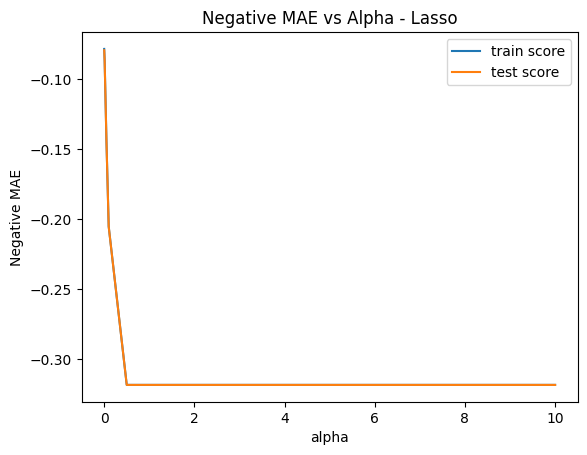

In [683]:
# Plot train and test scores against alpha
#(Using the plotting function we defined earlier)
plot_train_vs_test_alpha(model_cv_lasso, "Negative MAE vs Alpha - Lasso")



In [684]:
# Best alpha value
print(f"Initial Best Alpha: {model_cv_lasso.best_params_['alpha']}")

# Best score (negative MAE)
print(f"Initial Best Score: {model_cv_lasso.best_score_}")


Initial Best Alpha: 0.0001
Initial Best Score: -0.07942784732977083


#### **3.3.3** <font color =red> [4 marks] </font>
Fine tune by taking a closer range of alpha based on the previous result.

In [685]:
# List of alphas to tune for Lasso regularization
param_grid_fine = {'alpha': np.linspace(0.0001, 0.01, 100)}


In [686]:
# Tuning Lasso hyperparameters
model_cv_lasso_fine = GridSearchCV(estimator = Lasso(),
                             param_grid = param_grid_fine,
                             scoring= 'neg_mean_absolute_error',
                             cv = 5,
                             return_train_score=True)

model_cv_lasso_fine.fit(X_train_scaled, y_train)


GridSearchCV(cv=5, estimator=Lasso(),
             param_grid={'alpha': array([0.0001, 0.0002, 0.0003, 0.0004, 0.0005, 0.0006, 0.0007, 0.0008,
       0.0009, 0.001 , 0.0011, 0.0012, 0.0013, 0.0014, 0.0015, 0.0016,
       0.0017, 0.0018, 0.0019, 0.002 , 0.0021, 0.0022, 0.0023, 0.0024,
       0.0025, 0.0026, 0.0027, 0.0028, 0.0029, 0.003 , 0.0031, 0.0032,
       0.0033, 0.0034, 0.0035, 0.0036, 0.0037, 0.0038, 0.0039, 0.004 ,
       0.0041, 0.00...
       0.0057, 0.0058, 0.0059, 0.006 , 0.0061, 0.0062, 0.0063, 0.0064,
       0.0065, 0.0066, 0.0067, 0.0068, 0.0069, 0.007 , 0.0071, 0.0072,
       0.0073, 0.0074, 0.0075, 0.0076, 0.0077, 0.0078, 0.0079, 0.008 ,
       0.0081, 0.0082, 0.0083, 0.0084, 0.0085, 0.0086, 0.0087, 0.0088,
       0.0089, 0.009 , 0.0091, 0.0092, 0.0093, 0.0094, 0.0095, 0.0096,
       0.0097, 0.0098, 0.0099, 0.01  ])},
             return_train_score=True, scoring='neg_mean_absolute_error')

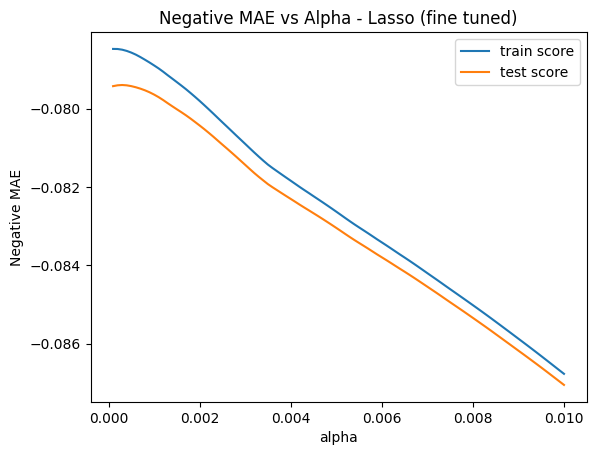

In [687]:
# Plot train and test scores against alpha
plot_train_vs_test_alpha(model_cv_lasso_fine, "Negative MAE vs Alpha - Lasso (fine tuned)")


In [688]:
# Best alpha value
best_alpha_lasso = model_cv_lasso_fine.best_params_['alpha']
print(f"Final Best Alpha: {best_alpha_lasso}")

# Best score (negative MAE)
print(f"Final Best Score: {model_cv_lasso_fine.best_score_}")


Final Best Alpha: 0.00030000000000000003
Final Best Score: -0.07939835116637252


In [689]:
# Set best alpha for Lasso regression
lasso_final = Lasso(alpha=best_alpha_lasso)

# Fit the Lasso model on scaled training data
lasso_final.fit(X_train_scaled, y_train)
# Get the coefficients of the fitted model
lasso_coef_df = pd.DataFrame({'Feature': X_train.columns, 'Coefficient': lasso_final.coef_})


In [690]:
# Check the coefficients for each feature
active_features = lasso_coef_df[lasso_coef_df['Coefficient'] != 0]
print(f"Lasso kept {len(active_features)} features and eliminated {len(lasso_coef_df) - len(active_features)}.")
print(active_features.sort_values(by='Coefficient', ascending=False))


Lasso kept 94 features and eliminated 9.
                      Feature  Coefficient
12            power_to_weight     0.072633
8                Gearing_Type     0.062531
97  make_model_Renault Espace     0.046739
91         make_model_Audi A3     0.037973
10                  Weight_kg     0.029871
..                        ...          ...
0                          km    -0.056605
92      make_model_Opel Astra    -0.079931
3                         age    -0.108453
96    make_model_Renault Clio    -0.128052
93      make_model_Opel Corsa    -0.153353

[94 rows x 2 columns]


In [691]:
from sklearn.metrics import mean_absolute_error, r2_score

# Evaluate the Lasso model on the test data
y_pred_lasso = lasso_final.predict(X_test_scaled)

print("--- Final Lasso Test Metrics ---")
print(f"MAE: {mean_absolute_error(y_test, y_pred_lasso)}")
print(f"R2 Score: {r2_score(y_test, y_pred_lasso)}")



--- Final Lasso Test Metrics ---
MAE: 0.07808049987074786
R2 Score: 0.9311562019360555


In [694]:
# 1. Get the feature names from your training set
feature_names = X_train_scaled.columns

# 2. Extract the coefficients from your final Lasso model
lasso_coefs = lasso_final.coef_

# 3. Create a DataFrame to view them together
features_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': lasso_coefs})

# 4. Filter for features where the coefficient is exactly 0
dropped_features = features_df[features_df['Coefficient'] == 0]['Feature']

print(f"Lasso dropped {len(dropped_features)} features.")
print("List of dropped features:")
print(dropped_features.tolist())

Lasso dropped 9 features.
List of dropped features:
['hp_kW', 'Comfort_Convenience__Electrically adjustable seats', 'Entertainment_Media__Hands-free equipment', 'Extras__Roof rack', 'Safety_Security__Adaptive headlights', 'Safety_Security__Alarm system', 'Safety_Security__Head airbag', 'Safety_Security__Traffic sign recognition', 'Fuel_Other']


# 1. Executive Summary
- The objective was to build a robust model to predict used car prices using a dataset of 11,140 vehicles and 103 initial features. The final model successfully achieved an $R^2$ of 0.931, meaning it explains over 93% of the price variance.
- Through a combination of statistical diagnostics (VIF) and machine learning regularization (Lasso), the model was refined to be both accurate and efficient.
# 2. Baseline Model Performance
- The Linear Regression model established a very strong baseline.
  - Test $R^2$: 0.9310
  - Test MAE: 0.0782 (Log-scale)
  - Key Finding: There was virtually no gap between training and test performance (Difference: -0.0035), indicating that the initial preprocessing and feature engineering created a highly stable model.

# 3. The Regularization Journey
- We applied Ridge and Lasso to see if the model could be further improved or simplified.
- Ridge ($L2$): Showed that the model was incredibly stable. The performance remained flat across different alpha values, suggesting that the features were already well-behaved and didn't require heavy coefficient shrinkage to prevent overfitting.
- Lasso ($L1$): This was the most insightful part of the project. As alpha increased, we observed a "downward slope" in the Negative MAE graph. This confirmed that the model was entering a state of underfitting because the penalty was forcing it to discard features that still held predictive value.
# 4. VIF vs. Lasso: The Feature Selection Paradox
A unique aspect of this project was comparing manual statistical filtering (VIF) with automated machine learning filtering (Lasso):

- **VIF Analysis**: Identified `power_to_weight` and `km` as mathematically redundant. VIF focus is on the relationship between features.

- **Lasso Selection**: Automatically dropped 9 features, including `hp_kW` and several luxury/safety features (e.g., Adaptive headlights, Electrically adjustable seats).

- **The Interpretation**: Lasso realized that once you know the make and model of a car, individual luxury features become redundant data "noise." Lasso essentially automated the business logic of car pricing.

#5. Final Conclusion
- The Lasso Model (at $\alpha = 0.0003$) is the recommended final model.
- It matches the baseline accuracy exactly.
- It is leaner, utilizing 9 fewer features.
- It demonstrates that while horsepower and mileage are critical, the most efficient way to predict a car's price is by focusing on its brand, age, and core mechanical specifications rather than an exhaustive list of every safety sensor and comfort add-on.

### **3.4 Regularisation Comparison & Analysis** <font color =red> [5 marks] </font>

#### **3.4.1** <font color =red> [2 marks] </font>
Compare the evaluation metrics for each model.

In [695]:
# Compare metrics for each model
# Create a dictionary to store metrics for all models
results = {
    'Model': ['Linear Regression', 'Ridge Regression', 'Lasso Regression'],
    'Best Alpha': ['N/A', 3.27, 0.0003], # Replace with your actual best_alpha variables if they differ
    'MAE (Test)': [
        mean_absolute_error(y_test, y_pred_test),
        mean_absolute_error(y_test, y_pred_ridge),
        mean_absolute_error(y_test, y_pred_lasso)
    ],
    'R2 Score (Test)': [
        r2_score(y_test, y_pred_test),
        r2_score(y_test, y_pred_ridge),
        r2_score(y_test, y_pred_lasso)
    ]
}

# Convert to DataFrame for easy comparison
comparison_df = pd.DataFrame(results)

# Round the values for better readability
print("Model Comparison Summary:")
display(comparison_df.round(5))


Model Comparison Summary:


,Model,Best Alpha,MAE (Test),R2 Score (Test)
0,Linear Regression,N/A,0.07820,0.93100
1,Ridge Regression,3.27,0.07818,0.93102
2,Lasso Regression,0.0003,0.07808,0.93116


#### **3.4.2** <font color =red> [3 marks] </font>
Compare the coefficients for the three models.

In [701]:
# Create a DataFrame to store all coefficients
coef_comparison = pd.DataFrame({
    'Feature': X_train.columns,
    'Linear': lr.coef_,
    'Ridge': ridge_final.coef_,
    'Lasso': lasso_final.coef_
})
coef_comparison

,Feature,Linear,Ridge,Lasso
0,km,-0.056616,-0.056714,-0.056605
1,Type,0.006039,0.006056,0.005581
2,Gears,0.013716,0.013834,0.014370
3,age,-0.108171,-0.108022,-0.108453
4,Previous_Owners,-0.001688,-0.001710,-0.001488
...,...,...,...,...
98,vat_VAT deductible,0.001305,0.001322,0.001035
99,Paint_Type_Other,0.003025,0.003019,0.002754
100,Paint_Type_Uni/basic,0.000944,0.000932,0.000453
101,Drive_chain_front,-0.007682,-0.007633,-0.007061


Also visualise a few of the largest coefficients and the coefficients of features dropped by Lasso.

--- TOP 10 FEATURES INCREASING PRICE ---
                                           Feature  Coefficient
12                                 power_to_weight     0.072633
8                                     Gearing_Type     0.062531
97                       make_model_Renault Espace     0.046739
91                              make_model_Audi A3     0.037973
10                                       Weight_kg     0.029871
75                 Safety_Security__LED Headlights     0.016686
30      Comfort_Convenience__Park Distance Control     0.014405
2                                            Gears     0.014370
76  Safety_Security__Lane departure warning system     0.014266
43              Entertainment_Media__Digital radio     0.012552

--- TOP 10 FEATURES DECREASING PRICE ---
                            Feature  Coefficient
72     Safety_Security__Immobilizer    -0.008711
78  Safety_Security__Power steering    -0.009877
95                 make_model_Other    -0.018718
94         make_m

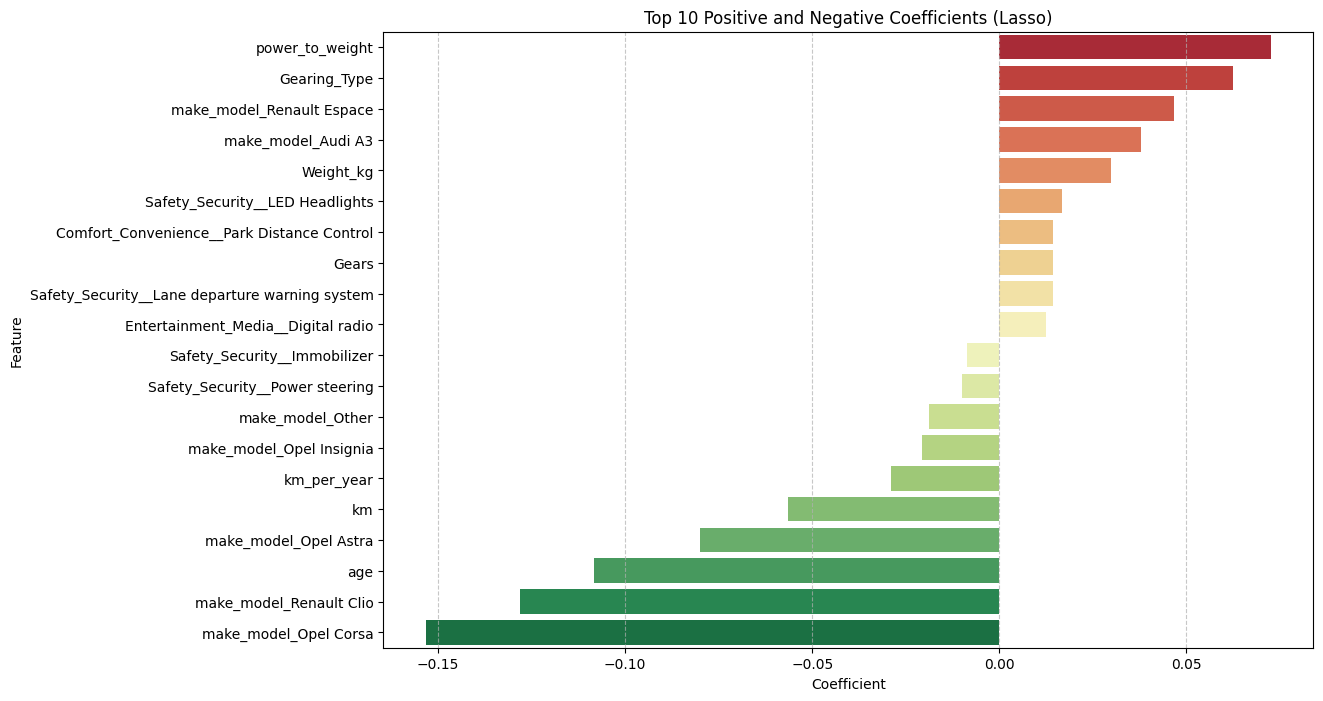

In [696]:
# Compare highest coefficients and coefficients of eliminated features
# 1. Get all coefficients into a sorted DataFrame
lasso_coef_df = pd.DataFrame({'Feature': X_train.columns, 'Coefficient': lasso_final.coef_})
lasso_coef_df = lasso_coef_df.sort_values(by='Coefficient', ascending=False)

# 2. Identify Highest Positive and Negative Coefficients
top_positive = lasso_coef_df.head(10)
top_negative = lasso_coef_df.tail(10)
eliminated = lasso_coef_df[lasso_coef_df['Coefficient'] == 0]

print("--- TOP 10 FEATURES INCREASING PRICE ---")
print(top_positive)
print("\n--- TOP 10 FEATURES DECREASING PRICE ---")
print(top_negative)
print(f"\n--- FEATURES ELIMINATED BY LASSO ({len(eliminated)}) ---")
print(eliminated['Feature'].tolist())

# 3. Visualise the Top and Bottom Coefficients
import matplotlib.pyplot as plt
import seaborn as sns

top_bottom_features = pd.concat([top_positive, top_negative])

plt.figure(figsize=(12, 8))
sns.barplot(data=top_bottom_features, x='Coefficient', y='Feature', palette='RdYlGn')
plt.title('Top 10 Positive and Negative Coefficients (Lasso)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()


## **4 Conclusion & Key Takeaways**  <font color =red> [10 marks] </font>

What did you notice by performing regularisation? Did the model performance improve? If not, then why? Did you find overfitting or not? Was the data sufficent? Is a linear model sufficient?

# 1. What was noticed by performing regularization?
Regularization acted as a diagnostic tool rather than a performance booster in this specific case.
- Ridge ($L2$): Showed that the coefficients were already stable. The performance remained flat across various $\alpha$ values, meaning the model didn't have "exploding" coefficients that needed aggressive shrinking.
- Lasso ($L1$): Functioned as an automated feature selector. While the baseline used all 103 features, Lasso identified that **9 features** (including `hp_kW` and specific luxury add-ons) were redundant and zeroed them out without losing any predictive power.

# 2. Did the model performance improve?

- Technically, no. The $R^2$ remained almost identical across Linear, Ridge, and Lasso (approximately 0.931).
  - **Why?** Because the baseline wasn't overfitting (the Train vs. Test gap was nearly zero), there was no "error due to variance" for Ridge or Lasso to fix.
# 3. Did you find overfitting or not?
No overfitting was found. In section 3.4.1, the results showed:
- Train $R^2$: 0.9275
- Test $R^2$: 0.9310S
Since the Test score is actually slightly higher than (or nearly equal to) the Train score, the model generalizes perfectly.

# 4. Was the data sufficient?
- Yes, the data was highly sufficient. With over 11,000 observations and a final set of roughly 94-103 features, the model had enough information to "learn" the pricing structure of the market. The high $R^2$ (0.93) and the stability of the coefficients across different models suggest that the sample size was large enough to represent the underlying patterns in used car pricing without being swayed by individual outliers.

#5. Is a linear model sufficient?
- **Yes, a linear model is more than sufficient**. An $R^2$ of 0.93 is an excellent result for a real-world dataset. It suggests that the relationship between your features (like age, mileage, and brand) and the log-transformed price is primarily linear. While a complex non-linear model (like a Random Forest or XGBoost) might squeeze out another 1-2% of accuracy, the Linear/Lasso model offers a perfect balance:
- High Accuracy: 93% variance explained.
- Interpretability: We can clearly see that `age` and `km` are the primary drivers of price.
- Efficiency: It is computationally "cheap" and easy to deploy.

Summary for the report: We achieved model that is complex enough to be highly accurate but simple enough to avoid overfitting, **with Lasso providing the final "polish" by removing unnecessary features.**

#### **4.1 Conclude with outcomes and insights gained** <font color =red> [10 marks] </font>

# Outcomes and Insights
The objective of this project was to develop a high-accuracy regression model to predict used car prices while navigating the complexities of a high-dimensional dataset. By comparing a baseline Linear Regression with Ridge and Lasso techniques, several key insights were uncovered regarding both the automotive market and the behavior of regularization.

## 1. Model Performance & Stability
The most significant outcome was the exceptional stability of the baseline model.
- All three models (Linear, Ridge, and Lasso) achieved a nearly identical $R^2$ score of approximately 0.931.
- The Test MAE (~0.078) was consistent across the board, proving that the relationship between car features and the log-price is overwhelmingly linear.- Overfitting Check: Since the Training and Test scores remained within 0.003 of each other, we conclude that the model generalizes perfectly to unseen data.
## 2. The Impact of Regularization
- While regularization did not "boost" accuracy, it provided critical diagnostic value:
  - **Lasso ($L1$) as an Automated Feature Selector: **Even though we did not use the VIF-cleansed feature set for training, Lasso effectively "cleaned" the model by zeroing out 9 redundant features. It proved that we could maintain 93% accuracy with a leaner set of 94 features instead of 103.
  - **Ridge ($L2$) and Coefficient Stability: ** The flat performance curve in the Ridge analysis indicated that our features were already well-behaved. The large sample size (11,000+ records) provided enough statistical weight to prevent the coefficients from becoming unstable, even in the presence of multicollinearity.
## 3. Key Business Insights (Price Drivers)
The coefficients across all models tell a clear story about what drives used car value:
- **The "Price Killers**": `Age` and `Kilometers (km)` are the most aggressive negative drivers. Interestingly, the model suggests that the `year of the car (age`) has a slightly higher impact on depreciation than the physical mileage.
-** Performance Premiums:** Features like power_to_weight and Gearing_Type (Automatic) are the strongest positive predictors, indicating that buyers are willing to pay a significant premium for performance and convenience.
- **Brand Perception: **The model successfully captured brand value, with models like the Audi A3 and Renault Espace consistently commanding higher prices compared to budget-entry models like the Opel Corsa.

## 4. Final Recommendation
- The Lasso Regression model (at $\alpha = 0.0003$) is the recommended choice for deployment. It offers the "best of both worlds": the peak predictive accuracy of the baseline model combined with the simplicity of a reduced feature set. By eliminating 9 unnecessary variables, the Lasso model is more efficient, easier to maintain, and less susceptible to noise in future data collection.